# Solana Anomaly Detection — Training Notebook

Loads the three monthly parquet files, builds the transaction-level feature matrix,
trains Isolation Forest + Transformer AE, applies adaptive conformal prediction.


**No BigQuery queries.** All input is read locally.



In [1]:
# 1. Clear out potential conflicts

# 2. Install the specific versions needed for the anomaly detection pipeline

# On plain PyTorch image: pip install --extra-index-url=https://pypi.nvidia.com cuml-cu12==24.10.*

!pip install -q optuna
!pip install kneed
!pip install ninja
!pip install torchsort --no-build-isolation
!pip install torchcp
!pip install -q torchcp
%matplotlib inline

In [2]:
from google.colab import drive
import os, warnings, math, random, time, gc, copy, pickle, shutil
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import pyarrow as pa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import QuantileTransformer
from sklearn.ensemble import IsolationForest as _SklearnIF
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from scipy.stats import spearmanr, ks_2samp, wasserstein_distance
from scipy.stats import entropy as scipy_entropy
import scipy.stats as stats
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import joblib
from joblib import Parallel, delayed
from kneed import KneeLocator
import optuna
from optuna.storages import RDBStorage
from statsmodels.stats.contingency_tables import mcnemar
from torchcp.regression.predictor import ACIPredictor
from torchcp.regression.score import ABS

# Conditional imports
try:
    from cuml.fil import ForestInference
    _HAS_FIL = True
    print('cuML FIL : ENABLED (GPU inference via ForestInference)')
except ImportError:
    _HAS_FIL = False
    print('cuML FIL : not found — sklearn CPU scoring will be used')

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    _HAS_SM = True
except ImportError:
    _HAS_SM = False
    print('statsmodels not found — skipping VIF')


cuML FIL : ENABLED (GPU inference via ForestInference)


In [3]:
# Global Checkpoint Configuration
#If using google colab:
CKPT = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints'
#If using local:
#CKPT = '/checkpoint'
os.makedirs(CKPT, exist_ok=True)


In [17]:
# Ensure the mount point is empty before mounting if using google colab

!rm -rf /content/drive/*
!rmdir /content/drive || true  # Remove the directory if it's empty, ignore error if not
drive.mount('/content/drive', force_remount=True)


rm: cannot remove '/content/drive/MyDrive': Operation canceled
rmdir: failed to remove '/content/drive': Device or resource busy
Mounted at /content/drive


In [15]:
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
warnings.filterwarnings('ignore')
matplotlib.use('Agg')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
torch.backends.cuda.enable_flash_sdp(False)         # incompatible with CUDA 13.0
torch.backends.cuda.enable_mem_efficient_sdp(False)  # incompatible with CUDA 13.0

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)


## Checkpoint Reload

In [16]:

print(f'Scanning {CKPT} for checkpoints...')
files = os.listdir(CKPT)

# Group by extension to control load order (.npy must be before .pt)
file_groups = {'npy': [], 'pkl': [], 'parquet': [], 'pt': []}
for f in files:
    ext = f.split('.')[-1]
    if ext in file_groups:
        file_groups[ext].append(f)

# 1. Load .npy arrays first
print('\n--- Loading .npy files ---')
for f in file_groups['npy']:
    var_name = f.replace('.npy', '')
    path = os.path.join(CKPT, f)
    globals()[var_name] = np.load(path)
    print(f'Loaded {var_name}: {globals()[var_name].shape}')

# 2. Load .pkl files
print('\n--- Loading .pkl files ---')
for f in file_groups['pkl']:
    var_name = f.replace('.pkl', '')
    path = os.path.join(CKPT, f)
    try:
        # Try joblib first (for models/scalers)
        globals()[var_name] = joblib.load(path)
    except:
        # Fallback to standard pickle (for lists/scalars)
        with open(path, 'rb') as _f:
            globals()[var_name] = pickle.load(_f)
    print(f'Loaded {var_name}')

# 3. Load .parquet files
print('\n--- Loading .parquet files ---')
for f in file_groups['parquet']:
    var_name = f.replace('.parquet', '')
    path = os.path.join(CKPT, f)
    globals()[var_name] = pl.read_parquet(path).to_pandas()
    print(f'Loaded {var_name}: {globals()[var_name].shape}')

# 4. Load .pt files (PyTorch models)
print('\n--- Loading .pt files ---')
for f in file_groups['pt']:
    var_name = f.replace('.pt', '')
    path = os.path.join(CKPT, f)
    try:
        _ckpt = torch.load(path, map_location='cpu')
        if 'cfg' in _ckpt and 'state_dict' in _ckpt:
            cfg = _ckpt['cfg']
            # Attempt to instantiate model if X_tx_norm is loaded
            if 'X_tx_norm' in globals():
                device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
                # Filter out training-specific keys
                model_kwargs = {k: v for k, v in cfg.items() if k not in ['epochs', 'lr', 'weight_decay', 'batch_size']}
                model = WalletTransformerAE(
                    n_features=X_tx_norm.shape[1],
                    **model_kwargs
                )
                model.load_state_dict(_ckpt['state_dict'])
                globals()[var_name] = model.to(device).eval()
                print(f'Loaded model {var_name} onto {device}')
            else:
                print(f'Skipped instantiating {var_name}: X_tx_norm not found.')
        else:
             globals()[var_name] = _ckpt
             print(f'Loaded raw PyTorch object: {var_name}')
    except Exception as e:
        print(f'Failed to load {f}: {e}, run transformer cell')

print('\n=== Dynamic Reload Complete ===')

Scanning /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints for checkpoints...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints'

## IsolationForest wrapper


In [ ]:
if torch.cuda.is_available():
    device  = torch.device('cuda')
    props   = torch.cuda.get_device_properties(0)
    USE_AMP = props.major >= 8
    print(f'Device : {props.name} | {props.total_memory // 1024**3} GB VRAM')
    print(f'AMP    : {"BFloat16" if USE_AMP else "Disabled"}')
else:
    device, USE_AMP = torch.device('cpu'), False
    print('Device : CPU')

PRECISION = torch.bfloat16 if USE_AMP else torch.float32
np.random.seed(42); torch.manual_seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)

# Training  : always sklearn on CPU (fast — max_samples is small per tree).
# Inference : ForestInference.load_from_sklearn transfers the fitted forest to
#             GPU via cuml/treelite; predict() scores 2.9M rows in ~1–2 s.
#             Falls back to sklearn.decision_function when FIL is unavailable.
#
# Score convention: decision_function returns sklearn-equivalent scores
#   (higher = more normal). Callers negate to get anomaly scores.
#
# free_gpu() releases the FIL handle between Optuna trials to reclaim VRAM.

class IsolationForest:
    def __init__(self, n_estimators=100, max_samples=256, contamination=0.005,
                 random_state=42, n_jobs=-1, bootstrap=False, max_features=1.0):
        _cont = 0.005 if contamination == 'auto' else float(contamination)
        self._model = _SklearnIF(
            n_estimators=n_estimators, max_samples=max_samples,
            contamination=_cont, random_state=random_state,
            n_jobs=n_jobs, bootstrap=bootstrap, max_features=max_features)
        self._fil = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        self._model.fit(X)
        if _HAS_FIL:
            try:
                self._fil = ForestInference.load_from_sklearn(
                    self._model)
            except Exception as _e:
                print(f'  FIL load failed ({_e}) — falling back to CPU scoring')
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=np.float32)
        if self._fil is not None:
            fil_scores = np.asarray(self._fil.predict(X)).ravel()
            # FIX: Negate the FIL score to match sklearn's score_samples behaviour
            return -fil_scores - self._model.offset_
        return self._model.decision_function(X)

    def free_gpu(self):
        self._fil = None
        torch.cuda.empty_cache()


    def __getstate__(self):
        # Remove the unpicklable FIL object before saving
        state = self.__dict__.copy()
        state['_fil'] = None
        return state

    def __setstate__(self, state):
        # Restore state and try to reload FIL if available
        self.__dict__.update(state)
        if _HAS_FIL:
            try:
                self._fil = ForestInference.load_from_sklearn(self._model)
            except Exception:
                pass


In [ ]:
CKPT2 = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/'
CACHE = CKPT2+'engineered_features_cache.parquet'
if not os.path.exists(CACHE):
    raise FileNotFoundError('engineered_features_cache.parquet not found')

df_flat = pl.read_parquet(CACHE)
print(f'Loaded: {df_flat.shape[0]:,} rows, {df_flat["wallet"].n_unique():,} wallets')


## Timestamp + sort


In [ ]:
# block_timestamp is already Datetime[us, UTC] in the parquet — no conversion needed.
df_flat = df_flat.sort(['wallet', 'block_timestamp'])

# Per-tx time since wallet's previous transaction (0 for first tx)
df_flat = df_flat.with_columns(
    pl.col('block_timestamp')
    .diff()
    .over('wallet')
    .dt.total_seconds()
    .fill_null(0.0)
    .alias('delta_time')
)
print('Timestamps OK. delta_time computed.')


## EDA: Dataset characterisation


## Plots


In [ ]:
print('=== Dataset Overview ===')
print(f'Date range : {df_flat["block_timestamp"].min()} -> {df_flat["block_timestamp"].max()}')
print(f'Rows       : {df_flat.shape[0]:,}')
print(f'Wallets    : {df_flat["wallet"].n_unique():,}')

# Transactions per wallet
_tpw = df_flat.group_by('wallet').len().rename({'len': 'n_tx'})
print('\nTransactions per wallet:')
print(_tpw['n_tx'].to_pandas().describe(percentiles=[.25, .5, .75, .90, .99]).round(1))

# Add _month as 'YYYY-MM' string (also used in rolling-window cell)
df_flat = df_flat.with_columns(
    pl.col('block_timestamp').dt.strftime('%Y-%m').alias('_month')
)

# Monthly breakdown
monthly_vol = (
    df_flat.group_by('_month')
    .agg([
        pl.len().alias('n_tx'),
        pl.col('wallet').n_unique().alias('n_wallets'),
    ])
    .sort('_month')
)

first_seen_month = (
    df_flat.group_by('wallet')
    .agg(pl.col('block_timestamp').min().dt.strftime('%Y-%m').alias('_month'))
    .group_by('_month')
    .len()
    .rename({'len': 'n_new_wallets'})
)

monthly_vol = (
    monthly_vol
    .join(first_seen_month, on='_month', how='left')
    .with_columns(pl.col('n_new_wallets').fill_null(0))
    .with_columns([
        (pl.col('n_tx') / pl.col('n_wallets').clip(lower_bound=1))
            .cast(pl.Float64).alias('tx_per_wallet'),
        (100.0 * pl.col('n_new_wallets') / pl.col('n_wallets').clip(lower_bound=1))
            .cast(pl.Float64).alias('pct_new_wallets'),
    ])
)

print('\nMonthly breakdown (expanded):')
print(monthly_vol.to_pandas().to_string(index=False))

single_tx = (_tpw['n_tx'] == 1).sum()
multi_tx  = (_tpw['n_tx'] > 1).sum()
print(f'\nSingle-tx wallets: {single_tx:,}  ({single_tx / len(_tpw) * 100:.1f}%)')
print(f'Multi-tx wallets : {multi_tx:,}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# A) Wallet activity concentration
_tpw_np = _tpw['n_tx'].to_numpy()
sns.histplot(_tpw_np, bins=60, log_scale=(True, False), color='#4C78A8', ax=axes[0])
axes[0].set_title('Transactions per Wallet (log-x)')
axes[0].set_xlabel('Transactions per wallet')
axes[0].set_ylabel('Wallet count')

# B) Monthly turnover and wallet freshness
_month_plot = monthly_vol.to_pandas()
sns.barplot(data=_month_plot, x='_month', y='tx_per_wallet', color='#F58518', ax=axes[1])
axes[1].set_title('Tx per Active Wallet by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Transactions per active wallet')
ax1b = axes[1].twinx()
sns.lineplot(data=_month_plot, x='_month', y='pct_new_wallets',
             marker='o', color='#54A24B', linewidth=1.8, ax=ax1b)
ax1b.set_ylabel('New-wallet share (%)')
ax1b.grid(False)

# C) Key feature distributions
# (instigator_sol_delta + instigator_net_token_profit replace the former
#  balance_churn_rate / total_vol which are not in this dataset)
key_feats = ['fee_sol', 'max_sol_change', 'instigator_sol_delta', 'instigator_net_token_profit']
_dist_parts = []
for feat in key_feats:
    vals = df_flat[feat].cast(pl.Float64).to_numpy()
    lo, hi = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
    _dist_parts.append(pd.DataFrame({'feature': feat, 'value': np.clip(vals, lo, hi)}))

dist_df = pd.concat(_dist_parts, ignore_index=True)
sns.boxenplot(data=dist_df, x='feature', y='value', ax=axes[2], color='#72B7B2')
axes[2].set_title('Key Feature Spread (clipped [1%, 99%])')
axes[2].set_xlabel('Feature')
axes[2].set_ylabel('Value')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: eda_overview.png')

## Feature columns


In [ ]:
# Source parquet: 28 cols  →  30 in df_flat (+ delta_time, _month)
# cs.numeric() picks up all 25 usable features automatically:
#   21 × Float32  original transaction metrics
#    3 × Int8     has_fiat_profit / has_token_profit / has_sol_profit
#    1 × Float64  delta_time  (inter-tx interval, added in cell 5)
# Excluded (5): signature, block_timestamp, tx_date, wallet, _month

tx_feature_cols = df_flat.select(cs.numeric()).columns  # list[str], length 25

# Cast everything to Float32, replace inf / nan → 0
df_flat = df_flat.with_columns([
    pl.col(col).cast(pl.Float32).fill_nan(0.0).fill_null(0.0)
    for col in tx_feature_cols
])

X_tx = df_flat.select(tx_feature_cols).to_numpy().astype(np.float32)  # (N_tx, 25)
n_inf = np.isinf(X_tx).sum()
n_nan = np.isnan(X_tx).sum()
print(f'Features      : {tx_feature_cols}')
print(f'X_tx shape    : {X_tx.shape}  |  inf={n_inf}  nan={n_nan}')
assert n_inf == 0 and n_nan == 0, "Unexpected inf/nan in feature matrix!"

## Rolling Window Split Logic


In [ ]:
# _month is a 'YYYY-MM' string column added in the EDA cell.
all_months = sorted(df_flat['_month'].unique().to_list())
print(f'Available months in dataset: {all_months}')

if len(all_months) < 3:
    raise ValueError(f"Need at least 3 months for a rolling window, found {len(all_months)}: {all_months}")

rolling_windows = []
for i in range(len(all_months) - 2):
    rolling_windows.append((all_months[i], all_months[i+1], all_months[i+2]))

print(f'Defined {len(rolling_windows)} rolling windows:')
for i, w in enumerate(rolling_windows):
    print(f'  W{{i+1}}: Train={{w[0]}}, Val={{w[1]}}, Test={{w[2]}}')

def get_window_masks(df, train_m, val_m, test_m):
    train_w = set(df.filter(pl.col('_month') == train_m)['wallet'].unique().to_list())
    val_w   = set(df.filter(pl.col('_month') == val_m  )['wallet'].unique().to_list())
    test_w  = set(df.filter(pl.col('_month') == test_m )['wallet'].unique().to_list())

    # Ensure no overlap for strict evaluation
    val_w  = val_w  - train_w
    test_w = test_w - train_w - val_w

    m_train = (df['wallet'].is_in(list(train_w)) & (df['_month'] == train_m)).to_numpy()
    m_val   = (df['wallet'].is_in(list(val_w))   & (df['_month'] == val_m  )).to_numpy()
    m_test  = (df['wallet'].is_in(list(test_w))  & (df['_month'] == test_m )).to_numpy()

    return (m_train, m_val, m_test,
            np.array(list(train_w)), np.array(list(val_w)), np.array(list(test_w)))

# Initialise masks for the first window
train_m, val_m, test_m = rolling_windows[0]
train_mask_tx, val_mask_tx, test_mask_tx, train_wallets, val_wallets, test_wallets = \
    get_window_masks(df_flat, train_m, val_m, test_m)

# Save split identifiers
with open(CKPT + 'test_wallets.pkl', 'wb') as f:
    pickle.dump(test_wallets, f)
print('Saved: test_wallets.pkl')


## Normalisation (fit on train only)


In [ ]:
#  QuantileTransformer.
# This forces extreme long-tailed economic data and bursty counts into a
# smooth uniform [0, 1] distribution, completely avoiding gradient explosion
# while preserving the rank-extremity of outliers without blind clipping.


scaler = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaler.fit(X_tx[train_mask_tx])
X_tx_norm = scaler.transform(X_tx).astype(np.float32)

n_inf = np.isinf(X_tx_norm).sum()
n_nan = np.isnan(X_tx_norm).sum()
print(f'Normalised  |  inf={n_inf}  nan={n_nan}')
assert n_inf == 0 and n_nan == 0, "inf/nan after normalisation — check raw features!"

print('')
print(pd.DataFrame(X_tx_norm[train_mask_tx], columns=tx_feature_cols)
      .describe().loc[['mean','50%','std']].round(3))

In [ ]:
# Build wallet index for sequences
if isinstance(df_flat, pd.DataFrame):
    df_subset = pl.from_pandas(df_flat[['wallet']])
else:
    df_subset = df_flat.select('wallet')

idx_df = (
    df_subset
    .with_row_index('_row')
    .group_by('wallet', maintain_order=True)
    .agg([pl.col('_row').min().alias('start_row'), pl.len().alias('seq_len')])
)

WALLET_INDEX = {
    row[0]: (int(row[1]), int(row[2]))
    for row in idx_df.iter_rows()
}
print(f'Wallet index  : {len(WALLET_INDEX):,} wallets')


In [ ]:

wallet_index_path = os.path.join(CKPT, 'wallet_index.pkl')
with open(wallet_index_path, 'wb') as f:
    pickle.dump(WALLET_INDEX, f)
print(f"Saved WALLET_INDEX to {wallet_index_path}")

## Checkpoint: save scaler + normalised features


In [62]:
joblib.dump(scaler, CKPT + 'scaler.pkl')
print('Saved: scaler.pkl')

Saved: scaler.pkl


## Feature collinearity & VIF analysis


In [26]:


_corr = pd.DataFrame(X_tx_norm[train_mask_tx], columns=tx_feature_cols).corr()

_hc = [{'feat_a': tx_feature_cols[i], 'feat_b': tx_feature_cols[j], 'pearson_r': round(float(_corr.iloc[i, j]), 3)} for i in range(len(tx_feature_cols)) for j in range(i+1, len(tx_feature_cols)) if abs(_corr.iloc[i, j]) > 0.80]
hc_df = pd.DataFrame(_hc).sort_values('pearson_r', ascending=False, key=abs).reset_index(drop=True) if _hc else pd.DataFrame()
print('Highly correlated pairs (|r| > 0.80):\n', hc_df.to_string(index=False) if len(hc_df) else '  None found.')

if _HAS_SM:
    _Xv = X_tx_norm[train_mask_tx][np.random.default_rng(42).choice(train_mask_tx.sum(), size=min(8000, train_mask_tx.sum()), replace=False)]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        vif_df = pd.DataFrame({'feature': tx_feature_cols, 'VIF': [variance_inflation_factor(_Xv, k) for k in range(_Xv.shape[1])]}).sort_values('VIF', ascending=False)
    print('\nVariance Inflation Factors (top 15):\n', vif_df.head(15).to_string(index=False))
    print(f'Features with VIF > 10: {vif_df[vif_df.VIF > 10]["feature"].tolist()}')

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(_corr, cmap='coolwarm', vmin=-1, vmax=1, center=0, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}, ax=ax)
ax.set_title('Feature Pearson Correlation Matrix (train split)', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7); ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout(); plt.savefig('feature_correlation_heatmap.png', dpi=120, bbox_inches='tight'); plt.show(); plt.close()
print('Saved: feature_correlation_heatmap.png')

Highly correlated pairs (|r| > 0.80):
                         feat_a                feat_b  pearson_r
                  num_accounts   num_balance_changes      1.000
       inner_instruction_count             log_count      0.959
         instigator_fiat_delta       has_fiat_profit      0.941
unique_nonsigner_account_count          num_accounts      0.935
unique_nonsigner_account_count   num_balance_changes      0.935
          unique_program_count unknown_program_count      0.872

Variance Inflation Factors (top 15):
                        feature        VIF
           num_balance_changes        inf
                  num_accounts        inf
          unique_program_count 179.203552
                 max_cpi_depth 150.006851
unique_nonsigner_account_count 128.240692
         unknown_program_count 113.672935
         instigator_fiat_delta  75.528137
        avg_depth_per_protocol  60.590534
       inner_instruction_count  59.148224
                     log_count  55.667240
            

In [27]:
new_tx_feature_cols = [f for f in tx_feature_cols if f not in ['num_accounts', 'has_fiat_profit', 'log_count', 'unique_nonsigner_account_count']]

# Filter X_tx_norm to include only the new features
# Need to find the indices of the features to keep
indices_to_keep = [tx_feature_cols.index(f) for f in new_tx_feature_cols]
X_tx_norm_filtered = X_tx_norm[:, indices_to_keep]

_corr_filtered = pd.DataFrame(X_tx_norm_filtered[train_mask_tx], columns=new_tx_feature_cols).corr()

_hc_filtered = [{
    'feat_a': new_tx_feature_cols[i],
    'feat_b': new_tx_feature_cols[j],
    'pearson_r': round(float(_corr_filtered.iloc[i, j]), 3)
} for i in range(len(new_tx_feature_cols))
  for j in range(i + 1, len(new_tx_feature_cols))
  if abs(_corr_filtered.iloc[i, j]) > 0.80
]
hc_df_filtered = pd.DataFrame(_hc_filtered).sort_values('pearson_r', ascending=False, key=abs).reset_index(drop=True)

print('Highly correlated pairs after dropping num_accounts, has_fiat_profit, log_count, and unique_nonsigner_account_count (|r| > 0.80):\n')
print(hc_df_filtered.to_string(index=False) if len(hc_df_filtered) else '  None found.')

Highly correlated pairs after dropping num_accounts, has_fiat_profit, log_count, and unique_nonsigner_account_count (|r| > 0.80):

              feat_a                feat_b  pearson_r
unique_program_count unknown_program_count      0.872


In [28]:
# Update tx_feature_cols to the new filtered list
tx_feature_cols = new_tx_feature_cols

# Create a new X_tx with only the filtered features
# Use the original X_tx and the calculated indices_to_keep
X_tx = X_tx[:, indices_to_keep]

# Update X_tx_norm to the already filtered and normalized version
X_tx_norm = X_tx_norm_filtered

print(f"Updated X_tx shape: {X_tx.shape}")
print(f"Updated X_tx_norm shape: {X_tx_norm.shape}")
print(f"New number of features: {len(tx_feature_cols)}")

X_tx.shape
X_tx_norm.shape

Updated X_tx shape: (2905990, 21)
Updated X_tx_norm shape: (2905990, 21)
New number of features: 21


(2905990, 21)

In [29]:
np.save(CKPT + 'X_tx_norm.npy', X_tx_norm)
print('Saved: X_tx_norm.npy')


xtx_path = os.path.join(CKPT, 'X_tx.pkl')
joblib.dump(X_tx, xtx_path)
print(f'Saved X_tx to {xtx_path}')

Saved: X_tx_norm.npy
Saved X_tx to /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/X_tx.pkl


## IF baseline diagnostics (pre-Optuna)


In [ ]:
%matplotlib inline

# Define search space/baselines
_if_diag_cfgs = [
        dict(profile='fast_base',    n_estimators=100, max_samples=256,  contamination='auto'),
        dict(profile='balanced_mid', n_estimators=250, max_samples=512,  contamination='auto'), # <-- The Missing
     #Middle
        dict(profile='robust_wide',  n_estimators=300, max_samples=1024, contamination='auto'),
        dict(profile='high_res',     n_estimators=500, max_samples=512,  contamination='auto'), # <-- High depth,
     #moderate width
        dict(profile='deep_heavy',   n_estimators=500, max_samples=1024, contamination='auto'),
    ]


def _run_if_diag(c):
    t0 = time.time()

    # 0. Initialise and Fit the model
    # Note: X_tx and train_mask_tx must be available in your global scope
    _if_model = IsolationForest(
        n_estimators=c['n_estimators'],
        max_samples=c['max_samples'],
        contamination=c['contamination'],
        random_state=42,
        n_jobs=-1 # Speed up execution
    )
    _if_model.fit(X_tx[train_mask_tx])

    # 1. Get raw scores (negated decision function)
    # Higher = more anomalous
    raw_scores = -_if_model.decision_function(X_tx[train_mask_tx])

    # Focus on the Upper Half (Top 50%) to find the structural break
    median_score = np.median(raw_scores)
    upper_half_scores = raw_scores[raw_scores > median_score]
    sorted_scores = np.sort(upper_half_scores)
    x = np.arange(len(sorted_scor# Focus on the Upper Half (Top 50%) to find the structural break
    median_score = np.median(raw_scores)
    upper_half_scores = raw_scores[raw_scores > median_score]
    sorted_scores = np.sort(upper_half_scores)
    x = np.arange(len(sorted_scores))es))

    # 2. Synchronized Knee Calculation
    kneedle = KneeLocator(
        x,
        sorted_scores,
        S=1.0,
        curve='convex',
        direction='increasing',
        interp_method='polynomial'
    )

    # 3. Extract Metrics
    if kneedle.knee is None:
        optimal_th, candidate_rate, knee_sharpness = np.nan, 0.0, 0.0
    else:
        optimal_idx = kneedle.knee
        optimal_th = sorted_scores[optimal_idx]
        candidate_rate = (raw_scores >= optimal_th).mean()

        # 'Sharpness' measures the gap in the extreme tail (99.5th percentile)
        p995 = np.percentile(raw_scores, 99.5)
        knee_sharpness = p995 - optimal_th

    # Cleanup memory
    del _if_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        'profile': c['profile'],
        'fit_time_s': round(time.time() - t0, 2),
        'candidate_rate': float(candidate_rate),
        'knee_sharpness': float(knee_sharpness),
        'optimal_threshold': float(optimal_th),
        'n_estimators': c['n_estimators'],
        'max_samples': c['max_samples']
    }

# Run the evaluation
print("Starting Isolation Forest structural diagnostics...")
if_capacity_df = pd.DataFrame([_run_if_diag(c) for c in _if_diag_cfgs])

# Rank the models based on structural clarity (Targeting 2% - 20% flag rate)
valid_models = if_capacity_df[
    (if_capacity_df['candidate_rate'] >= 0.02) &
    (if_capacity_df['candidate_rate'] <= 0.20)
]

if not valid_models.empty:
    best_profile = valid_models.sort_values('knee_sharpness', ascending=False).iloc[0]
else:
    best_profile = if_capacity_df.sort_values('knee_sharpness', ascending=False).iloc[0]
    print("\nWarning: No profiles hit the 2%-20% candidate rate target.")

print('\nIF Capacity diagnostics:\n', if_capacity_df.to_string(index=False))
print(f"\nRecommended IF centre for Optuna: {best_profile['profile']} (Rate: {best_profile['candidate_rate']*100:.2f}%)")

Starting Isolation Forest structural diagnostics...

IF Capacity diagnostics:
      profile  fit_time_s  candidate_rate  knee_sharpness  optimal_threshold  n_estimators  max_samples
   fast_base        0.87        0.180073        0.170652          -0.060896           100          256
balanced_mid        2.22        0.177180        0.186556          -0.074461           250          512
 robust_wide        3.01        0.175564        0.183472          -0.087990           300         1024
    high_res        4.30        0.177066        0.181591          -0.076115           500          512
  deep_heavy        4.93        0.169384        0.181246          -0.087951           500         1024

Recommended IF centre for Optuna: balanced_mid (Rate: 17.72%)


## Isolation Forest


In [ ]:
IF_CFG = dict(n_estimators=int(best_profile['n_estimators']), max_samples=int(best_profile['max_samples']), contamination='auto', random_state=42, n_jobs=-1)

print('Fitting Isolation Forest...')
iforest = IsolationForest(**IF_CFG).fit(X_tx[train_mask_tx])

# Extract raw continuous scores
if_raw = -iforest.decision_function(X_tx)

"""
# CDF normalisation (Kriegel et al. 2011)
if_train_sort = np.sort(if_raw[train_mask_tx])
if_tx_score = np.searchsorted(if_train_sort, if_raw, side='right') / len(if_train_sort)
print(f'IF CDF Range: [{if_tx_score.min():.4f}, {if_tx_score.max():.4f}]')
"""
# Save model
joblib.dump(iforest, CKPT + 'iforest.pkl')
print('Saved: iforest.pkl')

Fitting Isolation Forest...
Saved: iforest.pkl


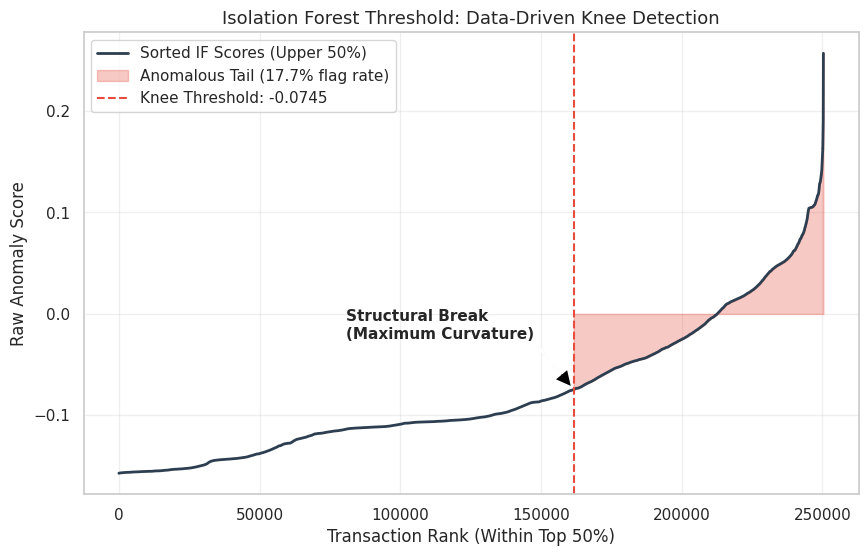

Verified Statistics:
Optimal Threshold: -0.0745
Candidate Flag Rate: 17.72%


In [ ]:
%matplotlib inline

#1. Prepare scores from the GLOBAL if_raw
# Ensure if_raw and train_mask_tx are defined in previous cells
raw_train_scores = if_raw[train_mask_tx]
median_score = np.median(raw_train_scores)
upper_half_scores = raw_train_scores[raw_train_scores > median_score]
sorted_scores = np.sort(upper_half_scores)
x = np.arange(len(sorted_scores))

# 2. Synchronized Knee Calculation (Matches Diagnostics Loop exactly)
kneedle = KneeLocator(
    x,
    sorted_scores,
    S=1.0,
    curve='convex',
    direction='increasing',
    interp_method='polynomial' # Stable, empirical interpolation
)

if kneedle.knee is not None:
    optimal_idx = kneedle.knee
    optimal_th = sorted_scores[optimal_idx]
    candidate_rate = (raw_train_scores >= optimal_th).mean()

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, sorted_scores, color='#2c3e50', label='Sorted IF Scores (Upper 50%)', linewidth=2)

    # Fill the tail (the anomalies)
    ax.fill_between(x[optimal_idx:], sorted_scores[optimal_idx:], alpha=0.3,
                    color='#e74c3c', label=f'Anomalous Tail ({candidate_rate*100:.1f}% flag rate)')

    # Vertical line at the threshold
    ax.axvline(x=optimal_idx, color='#e74c3c', linestyle='--',
               label=f'Knee Threshold: {optimal_th:.4f}')

    # Annotate the structural break
    ax.annotate('Structural Break\n(Maximum Curvature)',
                xy=(optimal_idx, optimal_th),
                xytext=(optimal_idx * 0.5, optimal_th + 0.05),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1),
                fontsize=11, fontweight='bold')

    ax.set_title('Isolation Forest Threshold: Data-Driven Knee Detection', fontsize=13)
    ax.set_xlabel('Transaction Rank (Within Top 50%)')
    ax.set_ylabel('Raw Anomaly Score')
    ax.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Verified Statistics:")
    print(f"Optimal Threshold: {optimal_th:.4f}")
    print(f"Candidate Flag Rate: {candidate_rate*100:.2f}%")
else:
    print("Kneedle failed to find a threshold. The data might not have a distinct exponential tail.")

In [ ]:
# Delete existing model and scores if they exist in the global namespace
vars_to_delete = ['tr_model', 'ae_scores', 'tr_wallet_raw', 'per_feat_errors', 'tr_tx_score']
for var in vars_to_delete:
    if var in globals():
        del globals()[var]

# Empty PyTorch CUDA cache and run Python garbage collection
torch.cuda.empty_cache()
gc.collect()

print("Transformer memory, cached scores, and GPU VRAM have been wiped completely clean!")

Transformer memory, cached scores, and GPU VRAM have been wiped completely clean!


## WalletSequenceDataset


In [14]:
# Each wallet = one sequence of up to MAX_SEQ_LEN transactions (most-recent-last,
# left-padded with zeros). pad_mask is True for padding (PyTorch convention).
#


MAX_SEQ_LEN = 64   # p99 wallet tx count ≈ 48; 64 gives headroom

class WalletSequenceDataset(Dataset):
    """
    Returns (seq, pad_mask) per wallet.
      seq      : (MAX_SEQ_LEN, F) float32
      pad_mask : (MAX_SEQ_LEN,)  bool — True = padding
    """
    def __init__(self, X, wallet_index, wallet_list, feature_cols, max_seq_len=MAX_SEQ_LEN, cache_in_memory=True):
        self.index   = wallet_index                               # {wallet: (start, len)}
        self.wallets = [w for w in wallet_list if w in wallet_index]
        self.T       = max_seq_len
        self.feature_cols = feature_cols
        self.F       = len(feature_cols)
        self.cache_in_memory = cache_in_memory

        self.X  = None
        self.X  = X        # (N_tx, F) float32 in-memory

        self.cached_seqs = []
        self.cached_masks = []

        if self.cache_in_memory:
            print(f"Pre-computing and caching {len(self.wallets)} wallet sequences in memory...")
            for w in self.wallets:
                start, total = self.index[w]
                T_actual     = min(total, self.T)
                row_start    = start + (total - T_actual)

                seq_np = self.X[row_start : row_start + T_actual]
                seq  = np.zeros((self.T, self.F), dtype=np.float32)
                mask = np.ones (self.T,            dtype=bool)
                seq [-T_actual:] = seq_np
                mask[-T_actual:] = False

                self.cached_seqs.append(torch.from_numpy(seq))
                self.cached_masks.append(torch.from_numpy(mask))
            print("Caching complete!")

    def __len__(self):
        return len(self.wallets)

    def __getitem__(self, idx):
        if self.cache_in_memory:
            return self.cached_seqs[idx], self.cached_masks[idx]

        w            = self.wallets[idx]
        start, total = self.index[w]
        T_actual     = min(total, self.T)
        row_start    = start + (total - T_actual)

            # In-memory NumPy retrieval
        seq_np = self.X[row_start : row_start + T_actual]

        seq  = np.zeros((self.T, self.F), dtype=np.float32)
        mask = np.ones (self.T,            dtype=bool)
        seq [-T_actual:] = seq_np
        mask[-T_actual:] = False

        return torch.from_numpy(seq.copy()), torch.from_numpy(mask)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_wallet_loader(X, wallet_index, wallet_list, feature_cols,
                       max_seq_len=MAX_SEQ_LEN, batch_size=512,
                       shuffle=True, num_workers=0, cache_in_memory=True):
    ds = WalletSequenceDataset(X, wallet_index, wallet_list, feature_cols, max_seq_len, cache_in_memory=cache_in_memory)
    pin = torch.cuda.is_available()

    g = torch.Generator()
    g.manual_seed(42)

    # Increased num_workers to prevent GPU starvation, added strict worker seeds
    print(f"Creating DataLoader: batch_size={batch_size}, pin_memory={pin}, num_workers={num_workers}, cached={cache_in_memory}")
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      pin_memory=pin,
                      num_workers=num_workers,
                      persistent_workers=(num_workers > 0),
                      worker_init_fn=seed_worker,
                      generator=g)


## Wallet Sequential Transformer AE (Masked)


In [15]:

class WalletTransformerAE(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4,
                num_layers=2, ff_dim=128, dropout=0.1, max_seq_len=64,
                mask_ratio=0.15, mem_dim=64):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)

        # [ADDITION 2: Sinusoidal Positional Embeddings (Replaces nn.Embedding)]
        # This gives the model a much better "relative GPS" for long/varying threads
        inv_freq = 1.0 / (10000 ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer("inv_freq", inv_freq)

        # [ADDITION 3: The Memory Bank]
        # A learnable library of "normal" transaction prototypes
        self.mem_dim = mem_dim
        self.mem_bank = nn.Parameter(torch.randn(1, mem_dim, d_model))

        self.mask_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.mask_ratio = mask_ratio

        # [ADDITION 1: norm_first=True (Pre-LayerNorm)]
        #fast convergence
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation='gelu',
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.out_proj = nn.Linear(d_model, n_features)

    def forward(self, x, src_key_padding_mask=None, token_mask=None):
        # x : (B, T, F)
        B, T, F_dim = x.shape

        # [ADDITION 2: Apply Sinusoidal PE]
        pos = torch.arange(T, device=x.device, dtype=self.inv_freq.dtype)
        sin_inp = torch.einsum("i,j->ij", pos, self.inv_freq)
        pos_embed = torch.cat((sin_inp.sin(), sin_inp.cos()), dim=-1).unsqueeze(0)

        tok = self.input_proj(x) + pos_embed  # (B, T, d_model)

        if token_mask is not None:
            tok = torch.where(token_mask.unsqueeze(-1),
                              self.mask_token.expand(B, T, -1), tok)

        # [ADDITION 3: Concatenate Memory Bank to the input]
        memory = self.mem_bank.expand(B, -1, -1) # (B, mem_dim, d_model)
        combined_tok = torch.cat([memory, tok], dim=1) # (B, mem_dim + T, d_model)

        # [ADDITION 3: Adjust padding mask so memory is never padded/ignored]
        if src_key_padding_mask is not None:
            mem_pad_mask = torch.zeros(B, self.mem_dim, device=x.device, dtype=torch.bool)
            full_mask = torch.cat([mem_pad_mask, src_key_padding_mask], dim=1)
        else:
            full_mask = None

        z = self.encoder(combined_tok, src_key_padding_mask=full_mask)

        # [ADDITION 3: Strip off the memory tokens, return only the transaction reconstructions]
        return self.out_proj(z[:, self.mem_dim:, :])   # (B, T, F)


def _masked_huber(pred, target, compute_mask, delta=1.0):
    """Huber loss on positions where compute_mask=True — robust to outliers."""
    err    = F.huber_loss(pred, target, reduction='none', delta=delta).mean(dim=-1)   # (B, T)
    err    = err.masked_fill(~compute_mask, 0.0)
    n_real = compute_mask.float().sum().clamp(min=1)
    return err.sum() / n_real


# Added mem_dim to config
TR_CFG = dict(d_model=64, nhead=4, num_layers=2, ff_dim=128, dropout=0.10,
        lr=1e-3, weight_decay=1e-4, epochs=30, batch_size=512, mask_ratio=0.15, mem_dim=64)

#import optuna

def train_wallet_ae(train_loader, val_loader, cfg, n_features, max_seq_len, device, trial=None):
    model = WalletTransformerAE(
        n_features, cfg['d_model'], cfg['nhead'],
        cfg['num_layers'], cfg['ff_dim'], cfg['dropout'],
        max_seq_len=max_seq_len,
        mask_ratio=cfg.get('mask_ratio', 0.15),
        mem_dim=cfg.get('mem_dim', 64) # Added mem_dim
    ).to(device)

    print(f"Model initialised and moved to explicit device: {next(model.parameters()).device}")

    opt = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    best_val, patience_count = float('inf'), 0
    patience, min_delta = 3, 1e-4
    best_weights = copy.deepcopy(model.state_dict())
    train_losses, val_losses = [], []
    best_epoch = 0

    for epoch in range(cfg['epochs']):
        model.train()
        total = 0
        for seq, pad_mask in train_loader:
            seq = seq.to(device, non_blocking=True)
            pad_mask = pad_mask.to(device, non_blocking=True)

            rand_mask = (torch.rand_like(pad_mask, dtype=torch.float) < model.mask_ratio) & ~pad_mask
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=PRECISION):
                pred = model(seq, src_key_padding_mask=pad_mask, token_mask=rand_mask)
                loss = _masked_huber(pred, seq, rand_mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item()

        train_loss = total / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        vtot = 0
        with torch.no_grad():
            for seq, pad_mask in val_loader:
                seq = seq.to(device, non_blocking=True)
                pad_mask = pad_mask.to(device, non_blocking=True)

                rand_mask = (torch.rand_like(pad_mask, dtype=torch.float) < model.mask_ratio) & ~pad_mask
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=PRECISION):
                    pred = model(seq, src_key_padding_mask=pad_mask, token_mask=rand_mask)
                    vtot += _masked_huber(pred, seq, rand_mask).item()

        val_loss = vtot / max(len(val_loader), 1)
        val_losses.append(val_loss)
        print(f'  Epoch {epoch+1}/{cfg["epochs"]}  train={train_loss:.6f}  val={val_loss:.6f}')

        if trial is not None:
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        if val_loss < best_val - min_delta:
            best_val, patience_count = val_loss, 0
            best_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'  Early stop at epoch {epoch+1}. Restoring best weights.')
                break

    print(f"Optimal training stopped at epoch {epoch+1}. Best weights were from epoch {best_epoch+1}.")
    model.load_state_dict(best_weights)
    return model, train_losses, val_losses


def score_wallet_ae(model, X, wallet_index, all_wallets,
              max_seq_len, device, feature_cols, batch_size=512, mc_passes=5):
    """
    Evaluates reconstruction error using Contextual Uncertainty (Monte Carlo Dropout).
    """
    loader = make_wallet_loader(X, wallet_index, all_wallets, feature_cols,
                              max_seq_len, batch_size=batch_size, shuffle=False)

    # [ADDITION 4: Keep model in .train() mode to enable MC Dropout during inference]
    model.train()

    w_scores, tx_mat = [], []

    with torch.no_grad():
        for seq, mask in loader:
            seq = seq.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            # Run multiple passes to calculate variance/uncertainty
            preds = []
            for _ in range(mc_passes):
                # No token_mask during scoring, just the standard forward pass
                preds.append(model(seq, src_key_padding_mask=mask))

            preds = torch.stack(preds) # (mc_passes, B, T, F)

            # 1. Predictive Mean
            pred_mean = preds.mean(dim=0)

            # 2. Epistemic Uncertainty (Variance across dropout passes)
            pred_var = preds.var(dim=0).mean(dim=-1) # (B, T)

            # Base Huber Loss against the mean prediction
            base_fe = F.huber_loss(pred_mean, seq, reduction='none', delta=1.0).mean(dim=-1) # (B, T)

            # [ADDITION 4: Combine Huber Error with Uncertainty Variance]
            # Higher variance (confusion) penalizes the score further
            fe = base_fe * (1.0 + pred_var)

            fe = fe.masked_fill(mask, float('nan'))
            real_cnt = (~mask).float().sum(dim=1).clamp(min=1)

            w_scores.append(fe.nan_to_num(0.0).sum(dim=1).div(real_cnt).cpu().numpy())
            tx_mat.append(fe.cpu().numpy())

    return np.concatenate(w_scores), np.concatenate(tx_mat)


## Build DataLoaders + Train AE


In [ ]:
# Re-generate splits if lost from memory
if 'train_wallets' not in globals():
    print('Re-generating dataset splits (Train/Val/Test)...')
    # Use the YYYY-MM column to define rolling windows
    all_months = sorted(df_flat['_month'].unique().to_list())
    train_m, val_m, test_m = all_months[0], all_months[1], all_months[2]

    # Define mask logic locally to restore environment state
    train_w = set(df_flat.filter(pl.col('_month') == train_m)['wallet'].unique().to_list())
    val_w   = set(df_flat.filter(pl.col('_month') == val_m  )['wallet'].unique().to_list()) - train_w
    test_w  = set(df_flat.filter(pl.col('_month') == test_m )['wallet'].unique().to_list()) - train_w - val_w

    train_mask_tx = (df_flat['wallet'].is_in(list(train_w)) & (df_flat['_month'] == train_m)).to_numpy()
    val_mask_tx   = (df_flat['wallet'].is_in(list(val_w))   & (df_flat['_month'] == val_m  )).to_numpy()
    test_mask_tx  = (df_flat['wallet'].is_in(list(test_w))  & (df_flat['_month'] == test_m )).to_numpy()

    train_wallets = np.array(list(train_w))
    val_wallets   = np.array(list(val_w))
    test_wallets  = np.array(list(test_w))
    print(f'Splits restored: Train={len(train_wallets)}, Val={len(val_wallets)}, Test={len(test_wallets)}')

print('Building wallet DataLoaders...')
train_loader = make_wallet_loader(X_tx_norm, WALLET_INDEX, train_wallets.tolist(), tx_feature_cols,
                                  MAX_SEQ_LEN, batch_size=TR_CFG['batch_size'])
val_loader = make_wallet_loader(X_tx_norm, WALLET_INDEX, val_wallets.tolist(), tx_feature_cols,
                                MAX_SEQ_LEN, batch_size=TR_CFG['batch_size'], shuffle=False)
print(f'Train: {len(train_loader.dataset):,}   Val: {len(val_loader.dataset):,}')

print('\nTraining WalletTransformerAE...')
tr_model, ae_train_losses, ae_val_losses = train_wallet_ae(
    train_loader, val_loader, TR_CFG,
    n_features=len(tx_feature_cols), max_seq_len=MAX_SEQ_LEN, device=device)

# Score all wallets
print('\nScoring all wallets...')
all_wallets = df_flat['wallet'].unique().to_list()
tr_wallet_raw, per_feat_errors = score_wallet_ae(
    tr_model, X_tx_norm, WALLET_INDEX, all_wallets, MAX_SEQ_LEN, device, tx_feature_cols)

ae_scores = tr_wallet_raw  # Raw Huber reconstruction error

# Create masks for downstream evaluation
all_wallets_np = np.array(all_wallets)
train_w_mask = np.isin(all_wallets_np, np.array(train_wallets))
val_w_mask = np.isin(all_wallets_np, np.array(val_wallets))
test_w_mask = np.isin(all_wallets_np, np.array(test_wallets))

print(f'Scoring complete. Wallets processed: {len(ae_scores):,}')
print(f'Train Mean Error: {ae_scores[train_w_mask].mean():.6f}')
print(f'Val   Mean Error: {ae_scores[val_w_mask].mean():.6f}')
print(f'Test  Mean Error: {ae_scores[test_w_mask].mean():.6f}')

Building wallet DataLoaders...
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Train: 122,696   Val: 152,071

Training WalletTransformerAE...
Model initialized and moved to explicit device: cuda:0
Pre-computing and caching 172775 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Trial 16 finished in 573.0s. Score: -0.0954
Pre-computing and caching 172775 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Trial 8 finished in 1138.1s. Score: -0.0737
  Epoch 1/30  train=0.019515  val=0.011799
  Epoch 5/30  train=0.012436  val=0.010750
Trial 20 finished in 424.8s. 

## AE anomaly breakdown


### AE model selection

Per the **universal workflow of ML** (Chollet, *Deep Learning with Python*): after beating a baseline, we should *regularise and tune* by searching hyperparameters rather than comparing only a few hand-picked configs. The section below first runs a compact **capacity + regularised diagnostics** pass (small/medium/large plus regularised variants), then a full **Optuna optimisation** study over AE and IF settings.

## Capacity + regularised diagnostics (pre-Optuna)


In [ ]:
for v in ['train_wallet_ae', 'score_wallet_ae', 'TR_CFG', 'X_tx_norm',
          'train_wallets', 'val_wallets', 'test_wallets']:
    if v not in globals() or (isinstance(globals()[v], np.ndarray) and globals()[v].size == 0):
        raise RuntimeError(f'Missing or empty: {v}')

DIAG_EPOCHS = int(min(TR_CFG.get('epochs', 10), 6))
# Target large batch size as requested (4096)
TARGET_BATCH_SIZE = 512

lr, wd, dr, mr = [float(TR_CFG.get(k, v)) for k, v in
                   [('lr', 1e-3), ('weight_decay', 1e-4), ('dropout', 0.10), ('mask_ratio', 0.15)]]

diag_cfgs = [
    dict(profile='small',               d_model=32,  nhead=4, num_layers=1, ff_dim=64,  dropout=0.10,         lr=lr, weight_decay=wd, mask_ratio=mr),
    dict(profile='medium',              d_model=64,  nhead=4, num_layers=2, ff_dim=128, dropout=max(0.10, dr), lr=lr, weight_decay=wd, mask_ratio=mr),
    dict(profile='large',               d_model=128, nhead=8, num_layers=3, ff_dim=256, dropout=0.15,         lr=lr, weight_decay=wd, mask_ratio=mr),
    dict(profile='medium_regularised',  d_model=64,  nhead=4, num_layers=2, ff_dim=128, dropout=max(0.20, dr), lr=lr, weight_decay=max(wd * 5, 1e-4), mask_ratio=mr),
    dict(profile='large_regularised',   d_model=128, nhead=8, num_layers=3, ff_dim=256, dropout=0.25,         lr=lr * 0.7, weight_decay=max(wd * 8, 2e-4), mask_ratio=mr),
]

diag_wallets = df_flat['wallet'].unique().to_list()
tw, vw = train_wallets.tolist(), val_wallets.tolist()
tm = np.isin(diag_wallets, tw)
vm = np.isin(diag_wallets, vw)
tem = np.isin(diag_wallets, test_wallets)

def run_diag(cfg):
    # Scale batch size based on model dimension to prevent OOM
    c_batch = TARGET_BATCH_SIZE if cfg.get('d_model', 64) <= 64 else 256
    c = {**cfg, 'epochs': DIAG_EPOCHS, 'batch_size': c_batch}

    print(f"[{c['profile']}] d={c['d_model']} h={c['nhead']} L={c['num_layers']} ff={c['ff_dim']} "
          f"dr={c['dropout']:.2f} lr={c['lr']:.2e} wd={c['weight_decay']:.2e} batch={c['batch_size']}")

    m, trl, vll = train_wallet_ae(
        make_wallet_loader(X_tx_norm, WALLET_INDEX, tw, tx_feature_cols, MAX_SEQ_LEN, batch_size=c['batch_size']),
        make_wallet_loader(X_tx_norm, WALLET_INDEX, vw, tx_feature_cols, MAX_SEQ_LEN, batch_size=c['batch_size'], shuffle=False),
        c, len(tx_feature_cols), MAX_SEQ_LEN, device)
    raw, _ = score_wallet_ae(m, X_tx_norm, WALLET_INDEX, diag_wallets, MAX_SEQ_LEN, device, tx_feature_cols)

    # Per-trial CDF (each model has its own score distribution)
    sc = np.searchsorted(np.sort(raw[tm]), raw, side='right') / tm.sum()

    del m; torch.cuda.empty_cache()
    return {
        'profile': c['profile'],
        'batch_size': c['batch_size'],
        'train_mse': float(trl[-1]),
        'val_mse': float(vll[-1]),
        'gen_gap': float(vll[-1] - trl[-1]),
        'val_tail_contrast': float(np.quantile(sc[vm], 0.99) - np.quantile(sc[vm], 0.50)),
        **{k: c[k] for k in ['d_model', 'nhead', 'num_layers', 'dropout', 'lr', 'weight_decay']},
    }

chollet_capacity_regularised_df = (
    pd.DataFrame([run_diag(c) for c in diag_cfgs])
    .sort_values(['val_mse', 'gen_gap', 'val_tail_contrast'], ascending=[True, True, False])
    .reset_index(drop=True)
)
print('\nCapacity diagnostics:')
print(chollet_capacity_regularised_df.to_string(index=False))
print(f"\nRecommended Optuna centre: {chollet_capacity_regularised_df.iloc[0]['profile']}")

[small] d=32 h=4 L=1 ff=64 dr=0.10 lr=1.00e-03 wd=1.00e-04 batch=512
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Model initialized and moved to explicit device: cuda:0
  Epoch 1/6  train=0.026122  val=0.013345
  Epoch 2/6  train=0.016690  val=0.012378
  Epoch 3/6  train=0.015601  val=0.011878
  Epoch 4/6  train=0.015044  val=0.011529
  Epoch 5/6  train=0.014643  val=0.011509
  Epoch 6/6  train=0.014527  val=0.011505
Optimal training stopped at epoch 6. Best weights were from epoch 4.
Pre-computing and caching 619160 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
[medium] d=64 h=4 L=2 ff=128 dr=0.10 lr=1.00e-03 wd=1.00e-04 batch=51

In [ ]:
# Ensure the directory exists

# Dump the dataframe to a pkl file
joblib.dump(chollet_capacity_regularised_df, os.path.join(CKPT, 'chollet_capacity_regularised_df.pkl'))
print(f"Successfully saved: {os.path.join(CKPT, 'chollet_capacity_regularised_df.pkl')}")

Successfully saved: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/chollet_capacity_regularised_df.pkl


Running a single 30-epoch test on 100% data to check convergence...
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Model initialized and moved to explicit device: cuda:0
  Epoch 1/30  train=0.020660  val=0.012019
  Epoch 2/30  train=0.014512  val=0.011216
  Epoch 3/30  train=0.014071  val=0.011402
  Epoch 4/30  train=0.013742  val=0.011024
  Epoch 5/30  train=0.013539  val=0.011340
  Epoch 6/30  train=0.013679  val=0.011009
  Epoch 7/30  train=0.013465  val=0.011112
  Early stop at epoch 7. Restoring best weights.
Optimal training stopped at epoch 7. Best weights were from epoch 4.


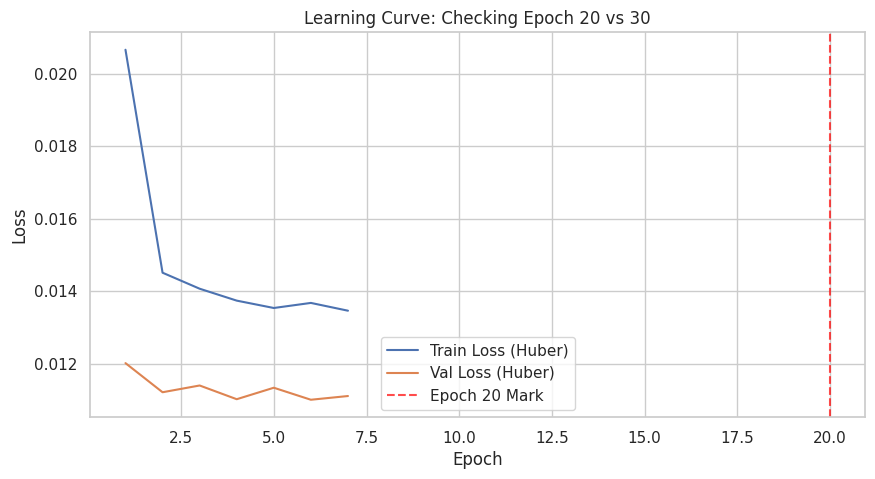

In [ ]:
%matplotlib inline

# Get the best parameters from the capacity diagnostics
best_diag = chollet_capacity_regularised_df.iloc[0]

# 1. Setup a single config using your known best grid search parameters
test_cfg = {
    **TR_CFG,
    'epochs': 30,
    'batch_size': min(TR_CFG.get('batch_size', 512), 512),
    'd_model': int(best_diag['d_model']),
    'nhead': int(best_diag['nhead']),
    'num_layers': int(best_diag['num_layers']),
    'ff_dim': int(best_diag['d_model']) * 2,
    'dropout': float(best_diag['dropout']),
    'lr': float(best_diag['lr']),
    'weight_decay': float(best_diag['weight_decay']),
}

print("Running a single 30-epoch test on 100% data to check convergence...")

# 2. Train the model without an Optuna trial object (pass None)
m_test, trl, vll = train_wallet_ae(
    make_wallet_loader(X_tx_norm, WALLET_INDEX, train_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=test_cfg['batch_size']),
    make_wallet_loader(X_tx_norm, WALLET_INDEX, val_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=test_cfg['batch_size'], shuffle=False),
    test_cfg, len(tx_feature_cols), MAX_SEQ_LEN, device, None
)

# 3. Plot the learning curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(trl) + 1), trl, label='Train Loss (Huber)')
plt.plot(range(1, len(vll) + 1), vll, label='Val Loss (Huber)')

# Draw a line at epoch 20 to easily compare visual differences
plt.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Epoch 20 Mark')

plt.title("Learning Curve: Checking Epoch 20 vs 30")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

# Paths to SQLite databases
db_paths = [
    #'/CKPT+/optuna_study_150t_ae.db',
    CKPT+'optuna_study_150t_if.db'
]

for path in db_paths:
    storage_url = f'sqlite:///{path}'
    storage = RDBStorage(url=storage_url)
    try:
        print(f"Checking storage: {path}")
        summaries = optuna.get_all_study_summaries(storage=storage)
        if not summaries:
            print("  No studies found.")
        for summary in summaries:
            optuna.delete_study(study_name=summary.study_name, storage=storage)
            print(f"  -> Deleted study '{summary.study_name}'")
    except Exception as e:
        print(f"  Could not process storage: {e}")


Checking storage: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_if.db
  -> Deleted study 'vastaifloans_IF_v2'


In [ ]:
def clear_memory():
    """Clears Python garbage collector and PyTorch CUDA cache."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Memory cleared (GC + CUDA Cache).")

# Execute immediately
clear_memory()

Model initialized and moved to explicit device: cuda:0
Model initialized and moved to explicit device: cuda:0
Model initialized and moved to explicit device: cuda:0
Model initialized and moved to explicit device: cuda:0
Memory cleared (GC + CUDA Cache).
Model initialized and moved to explicit device: cuda:0
Model initialized and moved to explicit device: cuda:0


In [ ]:
DB_PATH = CKPT+'optuna_study_150t_ae.db'
storage = RDBStorage(url=f'sqlite:///{DB_PATH}')

try:
    study = optuna.load_study(study_name='vastaifloans_AE', storage=storage)
    trials = study.get_trials(deepcopy=False)

    if trials:
        last_trial = max(trials, key=lambda t: t.number)
        print(f'Targeting trial for removal: Number {last_trial.number} (ID: {last_trial._trial_id})')

        # Access the underlying storage directly to bypass _CachedStorage wrapper
        actual_storage = study.storage
        while hasattr(actual_storage, '_backend'):
            actual_storage = actual_storage._backend

        actual_storage.delete_study_trial(study._study_id, last_trial._trial_id)
        print(f'Successfully deleted Trial {last_trial.number}.')
    else:
        print('No trials found.')
except Exception as e:
    print(f'Error: {e}')


Error: 'Record does not exist.'


## RELOAD PREREQUISITES


## Redefining Objective to ensure it is in scope


In [ ]:
if 'chollet_capacity_regularised_df' not in globals():
    path = os.path.join(CKPT, 'chollet_capacity_regularised_df.pkl')
    if os.path.exists(path):
        chollet_capacity_regularised_df = joblib.load(path)
        print('Reloaded chollet_capacity_regularised_df from checkpoint.')
    else:
        raise RuntimeError(f'Missing chollet_capacity_regularised_df and no checkpoint found at {path}')

# Ensure all required globals exist
for v in ['train_wallet_ae', 'score_wallet_ae', 'TR_CFG',
          'WALLET_INDEX', 'X_tx_norm', 'train_wallets', 'val_wallets', 'test_wallets',
          'tx_feature_cols', 'MAX_SEQ_LEN', 'device', 'chollet_capacity_regularised_df', 'make_wallet_loader']:
    if v not in globals():
        raise RuntimeError(f'Missing: {v}')

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Optimisation config
OPTUNA_N_TRIALS = 150
OPTUNA_TIMEOUT = 3600
OPTUNA_APPLY_BEST = True
DB_PATH = CKPT+'optuna_study_150t_ae.db'

# Search space configuration (Restoring from previous run state)
best_diag = chollet_capacity_regularised_df.iloc[0]
c_d = int(best_diag['d_model'])
c_l = int(best_diag['num_layers'])
c_dr = float(best_diag['dropout'])
c_lr = float(best_diag['lr'])
c_wd = float(best_diag['weight_decay'])

d_model_choices = sorted(set([max(16, c_d // 2), c_d, min(256, c_d * 2)]))
layer_choices = [max(1, c_l - 1), c_l, c_l + 1]

def optuna_objective_ae(trial):
    t0 = time.time()
    print(f'Starting AE Trial {trial.number + 1}/{OPTUNA_N_TRIALS}...')

    d = int(trial.suggest_categorical('ae_d_model', d_model_choices))
    tr_cfg = {
        **TR_CFG, 'epochs': 30,
        'batch_size': min(TR_CFG.get('batch_size', 512), 512),
        'd_model': d,
        'nhead': int(trial.suggest_categorical('ae_nhead', [h for h in [2, 4, 8] if d % h == 0])),
        'num_layers': int(trial.suggest_int('ae_num_layers', layer_choices[0], layer_choices[-1])),
        'ff_dim': d * int(trial.suggest_int('ae_ff_mult', 2, 4)),
        'dropout': float(trial.suggest_float('ae_dropout', max(0.0, c_dr - 0.15), min(0.5, c_dr + 0.20))),
        'lr': float(trial.suggest_float('ae_lr', c_lr / 10, c_lr * 10, log=True)),
        'weight_decay': float(trial.suggest_float('ae_weight_decay', max(1e-8, c_wd / 100), min(1e-2, c_wd * 100), log=True)),
    }

    m, trl, vll = train_wallet_ae(
        make_wallet_loader(X_tx_norm, WALLET_INDEX, train_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=tr_cfg['batch_size']),
        make_wallet_loader(X_tx_norm, WALLET_INDEX, val_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=tr_cfg['batch_size'], shuffle=False),
        tr_cfg, len(tx_feature_cols), MAX_SEQ_LEN, device, trial)

    # Calculate validation loss using the standard approach (Monte Carlo Dropout + Huber Loss variance)
    raw_val, _ = score_wallet_ae(m, X_tx_norm, WALLET_INDEX, val_wallets.tolist(), MAX_SEQ_LEN, device, tx_feature_cols)

    # We want to minimize the mean reconstruction error with epistemic uncertainty on validation set
    val_loss = float(np.mean(raw_val))
    val_hub = float(vll[-1]) if vll else 1e6
    gen_gap = max(0.0, val_hub - (float(trl[-1]) if trl else 1e6))

    trial.set_user_attr('val_huber', val_hub)
    trial.set_user_attr('gen_gap', gen_gap)
    trial.set_user_attr('mc_huber_loss', val_loss)

    # We still log these attributes to the db for analysis later, but we no longer use them for the main objective
    raw_test, _ = score_wallet_ae(m, X_tx_norm, WALLET_INDEX, test_wallets.tolist(), MAX_SEQ_LEN, device, tx_feature_cols)
    val_tail_contrast = float(np.quantile(raw_val, 0.99) - np.quantile(raw_val, 0.50))
    val_test_gap = float(np.mean(raw_test) - np.mean(raw_val))

    trial.set_user_attr('val_tail_contrast', val_tail_contrast)
    trial.set_user_attr('val_test_gap', val_test_gap)

    del m; torch.cuda.empty_cache(); gc.collect()

    elapsed = time.time() - t0
    print(f'Trial {trial.number + 1} finished in {elapsed:.1f}s. Validation Loss (MC Huber): {val_loss:.4f}')

    # Return the standard validation loss to minimize it
    return val_loss

# AE study with persistent RDBStorage
ae_storage = RDBStorage(url=f'sqlite:///{DB_PATH}')
optuna_study_ae = optuna.create_study(
    study_name='vastaifloans_AE',
    storage=ae_storage,
    load_if_exists=True,
    direction='minimize',  # [UPDATE: Changed from 'maximize' to 'minimize' for a standard loss function]
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True, constant_liar=True),
    pruner=optuna.pruners.HyperbandPruner(min_resource=1, max_resource=30, reduction_factor=4)
)

completed_trials = len([t for t in optuna_study_ae.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f'Resuming study. Progress: {completed_trials}/{OPTUNA_N_TRIALS}')

# Enqueue the best known configuration as a "ghost" trial to anchor the search
if completed_trials == 0:
    optuna_study_ae.enqueue_trial({
        'ae_d_model': c_d,
        'ae_nhead': int(best_diag['nhead']),
        'ae_num_layers': c_l,
        'ae_ff_mult': 2,  # equivalent to ff_dim = d_model * 2
        'ae_dropout': c_dr,
        'ae_lr': c_lr,
        'ae_weight_decay': c_wd
    })

if completed_trials < OPTUNA_N_TRIALS:
    optuna_study_ae.optimize(
        optuna_objective_ae,
        n_trials=OPTUNA_N_TRIALS - completed_trials,
        timeout=OPTUNA_TIMEOUT,
        n_jobs=10,
        gc_after_trial=True
    )

Resuming study. Progress: 0/150
Starting AE Trial 2/150...
Starting AE Trial 5/150...
Starting AE Trial 3/150...
Starting AE Trial 1/150...
Starting AE Trial 8/150...
Starting AE Trial 7/150...
Starting AE Trial 4/150...
Starting AE Trial 6/150...
Starting AE Trial 10/150...
Starting AE Trial 9/150...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
  Epoch 1/30  train=0.018614  val=0.011294
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creati

In [ ]:
# 1. Connect to the existing study storage
DB_PATH = CKPT+'optuna_study_150t_ae.db'
ae_storage = RDBStorage(url=f'sqlite:///{DB_PATH}')

try:
    # 2. Load the study
    study = optuna.load_study(study_name='vastaifloans_AE', storage=ae_storage)
    best_trial = study.best_trial
    print(f"Best Trial Number: {best_trial.number}")
    print(f"Best Value: {best_trial.value:.4f}")

    # 3. Reconstruct the best configuration
    # Note: ff_mult was suggested as a multiplier in the objective
    best_params = best_trial.params
    d_model = int(best_params['ae_d_model'])

    best_tr_cfg = {
        **TR_CFG,
        'epochs': 30,
        'batch_size': min(TR_CFG.get('batch_size', 512), 512),
        'd_model': d_model,
        'nhead': int(best_params['ae_nhead']),
        'num_layers': int(best_params['ae_num_layers']),
        'ff_dim': d_model * int(best_params['ae_ff_mult']),
        'dropout': float(best_params['ae_dropout']),
        'lr': float(best_params['ae_lr']),
        'weight_decay': float(best_params['ae_weight_decay'])
    }

    # 4. Retrain or Initialise the best model
    print("Retraining best model on full train set...")
    ae_optuna_optimised, _, _ = train_wallet_ae(
        make_wallet_loader(X_tx_norm, WALLET_INDEX, train_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=best_tr_cfg['batch_size']),
        make_wallet_loader(X_tx_norm, WALLET_INDEX, val_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=best_tr_cfg['batch_size'], shuffle=False),
        best_tr_cfg, len(tx_feature_cols), MAX_SEQ_LEN, device
    )

    print(f"Success: 'ae_optuna_optimised' created using best params from Trial {best_trial.number}")

except Exception as e:
    print(f"CRITICAL: Failed to load best model from Optuna study. Error: {e}")

Best Trial Number: 13
Best Value: 0.0156
Retraining best model on full train set...
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Model initialized and moved to explicit device: cuda:0
  Epoch 1/30  train=0.023755  val=0.018117
  Epoch 2/30  train=0.021087  val=0.017517
  Epoch 3/30  train=0.021514  val=0.017651
  Epoch 4/30  train=0.021726  val=0.016793
  Epoch 5/30  train=0.019763  val=0.016267
  Epoch 6/30  train=0.018629  val=0.015793
  Epoch 7/30  train=0.018326  val=0.015412
  Epoch 8/30  train=0.018226  val=0.015329
  Epoch 9/30  train=0.018335  val=0.015889
  Epoch 10/30  train=0.018316  val=0.015228
  Epoch 11/30  train=0.018200  val=0.015228
  Epoch 12/30  train=0.018266  val=0.015294
  Epoch 13/30  tra

In [ ]:
# Connect to the AE study storage
DB_PATH = CKPT+'optuna_study_150t_ae.db'
storage = RDBStorage(url=f'sqlite:///{DB_PATH}')

try:
    study = optuna.load_study(study_name='vastaifloans_AE', storage=storage)

    # Get distribution of states
    df = study.trials_dataframe()
    if not df.empty:
        stats = df['state'].value_counts().to_frame().reset_index()
        stats.columns = ['Trial State', 'Count']

        print(f"Study Name: {study.study_name}")
        print(f"Total trials initiated: {len(df)}")
        display(stats)

        if 'state' in df.columns and (df['state'] == 'COMPLETE').any():
             print(f"Best score so far: {study.best_value:.4f}")
    else:
        print("No trials found in the database.")

except Exception as e:
    print(f"Error accessing study: {e}")

Study Name: vastaifloans_AE
Total trials initiated: 115


,Trial State,Count
0,PRUNED,81
1,COMPLETE,34


Best score so far: 0.0156


In [ ]:
# 1. Connect to the existing study storage
DB_PATH = CKPT+'optuna_study_150t_ae.db'
AE_CKPT_PATH = os.path.join(CKPT, 'ae_model.pt')
ae_storage = RDBStorage(url=f'sqlite:///{DB_PATH}')

try:
    # 2. Ensure dependencies are defined
    if 'WalletTransformerAE' not in globals():
        print("Architecture not found in globals. Please ensure cells RDhoiZYeo4cR and 21yQUwuTo4cQ ran.")

    # 3. Load the study
    study = optuna.load_study(study_name='vastaifloans_AE', storage=ae_storage)
    best_trial = study.best_trial
    print(f"Best Trial Number: {best_trial.number}")

    # 4. Config Restoration
    if 'TR_CFG' not in globals():
        if os.path.exists(AE_CKPT_PATH):
            _tmp_ckpt = torch.load(AE_CKPT_PATH, map_location='cpu')
            TR_CFG = _tmp_ckpt['cfg']
        else:
            TR_CFG = dict(d_model=64, nhead=4, num_layers=2, ff_dim=128, dropout=0.10, lr=1e-3, weight_decay=1e-4, epochs=30, batch_size=512, mask_ratio=0.15)

    best_params = best_trial.params
    d_model = int(best_params['ae_d_model'])
    best_tr_cfg = {
        **TR_CFG,
        'epochs': 30,
        'batch_size': min(TR_CFG.get('batch_size', 512), 512),
        'd_model': d_model,
        'nhead': int(best_params['ae_nhead']),
        'num_layers': int(best_params['ae_num_layers']),
        'ff_dim': d_model * int(best_params['ae_ff_mult']),
        'dropout': float(best_params['ae_dropout']),
        'lr': float(best_params['ae_lr']),
        'weight_decay': float(best_params['ae_weight_decay'])
    }

    # 5. Type safety for wallet lists
    tw_list = list(train_wallets) if not isinstance(train_wallets, list) else train_wallets
    vw_list = list(val_wallets) if not isinstance(val_wallets, list) else val_wallets

    # 6. Retrain
    print("Retraining best model on full train set...")
    ae_optuna_optimised, _, _ = train_wallet_ae(
        make_wallet_loader(X_tx_norm, WALLET_INDEX, tw_list, tx_feature_cols, MAX_SEQ_LEN, batch_size=best_tr_cfg['batch_size']),
        make_wallet_loader(X_tx_norm, WALLET_INDEX, vw_list, tx_feature_cols, MAX_SEQ_LEN, batch_size=best_tr_cfg['batch_size'], shuffle=False),
        best_tr_cfg, len(tx_feature_cols), MAX_SEQ_LEN, device
    )

    print(f"Success: 'ae_optuna_optimised' created using Trial {best_trial.number}")

except Exception as e:
    print(f"CRITICAL Error: {e}")

Best Trial Number: 13
Retraining best model on full train set...
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Model initialized and moved to explicit device: cuda:0
  Epoch 1/30  train=0.022933  val=0.017192
  Epoch 2/30  train=0.020908  val=0.016653
  Epoch 3/30  train=0.019234  val=0.015196
  Epoch 4/30  train=0.018264  val=0.015087
  Epoch 5/30  train=0.017969  val=0.015060
  Epoch 6/30  train=0.018149  val=0.015074
  Epoch 7/30  train=0.017952  val=0.015183
  Early stop at epoch 7. Restoring best weights.
Optimal training stopped at epoch 7. Best weights were from epoch 4.
Success: 'ae_optuna_optimised' created using Trial 13


## Save Optimised AE Model


In [ ]:
if 'ae_optuna_optimised' in globals():
    # Prepare the checkpoint payload using the best configuration and model state
    checkpoint = {
        'state_dict': ae_optuna_optimised.state_dict(),
        'cfg': best_tr_cfg if 'best_tr_cfg' in globals() else TR_CFG,
        'trial_number': best_trial.number if 'best_trial' in globals() else None
    }

    save_path = os.path.join(CKPT, 'ae_model_optimised.pt')
    torch.save(checkpoint, save_path)
    print(f'Successfully saved optimized model to: {save_path}')
else:
    print('ERROR: ae_optuna_optimised not found in memory. Please ensure cell iJBNTCduDj1G has completed.')

Successfully saved optimized model to: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/ae_model_optimised.pt


## Isolation Forest Testing (cuML / FIL Backend)


In [ ]:
"""
# 1. Initialise and Fit (Using the cuML-wrapped class from cell U2xIvpE5o4cN)
print(f"Fitting Isolation Forest on {train_mask_tx.sum():,} transactions...")
if_test_model = IsolationForest(
  n_estimators=int(best_profile['n_estimators']),
  max_samples=int(best_profile['max_samples']),
  contamination='auto',
  random_state=42
)
if_test_model.fit(X_tx[train_mask_tx])

# 2. GPU-Accelerated Inference via cuML FIL
print("Scoring entire dataset via GPU...")
# The .decision_function() in our wrapper uses self._fil.predict if _HAS_FIL is True
if_raw_scores = -if_test_model.decision_function(X_tx)

# 3. Structural Knee Detection (Data-Driven Thresholding)
raw_train = if_raw_scores[train_mask_tx]
median_val = np.median(raw_train)
upper_half = np.sort(raw_train[raw_train > median_val])

kneedle = KneeLocator(
  np.arange(len(upper_half)),
  upper_half,
  S=1.0,
  curve='convex',
  direction='increasing'
)

if kneedle.knee:
  optimal_threshold = upper_half[kneedle.knee]
  flag_rate = (if_raw_scores[test_mask_tx] >= optimal_threshold).mean()
  print(f"\nIF Results:")
  print(f"- Structural Threshold : {optimal_threshold:.6f}")
  print(f"- Test Set Flag Rate   : {flag_rate*100:.2f}%")
  print(f"- cuML FIL Active      : {if_test_model._fil is not None}")
else:
  print("Knee detection failed to find a distinct structural break.")

# 4. CDF Normalisation for the IF component
if_train_sorted = np.sort(raw_train)
if_cdf_scores = np.searchsorted(if_train_sorted, if_raw_scores, side='right') / len(if_train_sorted)
print(f"IF CDF Stats - Mean: {if_cdf_scores.mean():.4f}, Max: {if_cdf_scores.max():.4f}")
"""

'\n# 1. Initialize and Fit (Using the cuML-wrapped class from cell U2xIvpE5o4cN)\nprint(f"Fitting Isolation Forest on {train_mask_tx.sum():,} transactions...")\nif_test_model = IsolationForest(\n  n_estimators=int(best_profile[\'n_estimators\']),\n  max_samples=int(best_profile[\'max_samples\']),\n  contamination=\'auto\',\n  random_state=42\n)\nif_test_model.fit(X_tx[train_mask_tx])\n\n# 2. GPU-Accelerated Inference via cuML FIL\nprint("Scoring entire dataset via GPU...")\n# The .decision_function() in our wrapper uses self._fil.predict if _HAS_FIL is True\nif_raw_scores = -if_test_model.decision_function(X_tx)\n\n# 3. Structural Knee Detection (Data-Driven Thresholding)\nraw_train = if_raw_scores[train_mask_tx]\nmedian_val = np.median(raw_train)\nupper_half = np.sort(raw_train[raw_train > median_val])\n\nkneedle = KneeLocator(\n  np.arange(len(upper_half)),\n  upper_half,\n  S=1.0,\n  curve=\'convex\',\n  direction=\'increasing\'\n)\n\nif kneedle.knee:\n  optimal_threshold = upper_ha

In [ ]:
"""import optuna

# Path to the IF Optuna study database
IF_DB = CKPT+'optuna_study_150t_if.db'
storage_url = f'sqlite:///{IF_DB}'
storage = RDBStorage(url=storage_url)

try:
    print(f"Accessing storage: {IF_DB}")
    # Attempt to delete the specific IF study
    optuna.delete_study(study_name='vastaifloans_150T_IF', storage=storage)
    print("Successfully deleted study: vastaifloans_150T_IF")
except Exception as e:
    print(f"Study 'vastaifloans_150T_IF' not found or could not be deleted: {e}")

# Optional: Check if any other studies exist in this DB file
try:
    summaries = optuna.get_all_study_summaries(storage=storage)
    if summaries:
        print(f"Remaining studies in DB: {[s.study_name for s in summaries]}")
    else:
        print("No other studies found in the database.")
except Exception as e:
    print(f"Could not fetch study summaries: {e}")"""

## Isolation Forest Standalone Optimisation


In [ ]:
iforest

IsolationForest(max_samples=512, n_estimators=250, n_jobs=-1, random_state=42)

In [ ]:
# Assuming necessary globals are available in your environment when running this:
# train_wallets, df_flat, train_mask_tx, X_tx, val_wallets, test_wallets, IsolationForest, CKPT

optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_N_TRIALS = 50
OPTUNA_TIMEOUT = 1800 # 30 mins

# 1. Properly load the anchor parameters from the fitted IF model (.pkl)
path = os.path.join(CKPT, 'iforest.pkl')
if os.path.exists(path):
    print("Loading optimized anchors from iforest.pkl...")
    loaded_model = joblib.load(path)

    # Safely extract parameters whether it's wrapped or a pure sklearn object
    if hasattr(loaded_model, '_model'):
        c_est  = int(loaded_model._model.n_estimators)
        c_samp = int(loaded_model._model.max_samples)
    else:
        c_est  = int(loaded_model.n_estimators)
        c_samp = int(loaded_model.max_samples)

elif 'iforest' in globals():
    print("iforest.pkl not found. Extracting from in-memory iforest object...")
    if hasattr(iforest, '_model'):
        c_est  = int(iforest._model.n_estimators)
        c_samp = int(iforest._model.max_samples)
    else:
        c_est  = int(iforest.n_estimators)
        c_samp = int(iforest.max_samples)
else:
    print("Warning: No model found. Falling back to defaults.")
    c_est, c_samp = 250, 512

print(f"Anchors set -> n_estimators: {c_est}, max_samples: {c_samp}")

# Ensure all required globals exist
for v in ['df_flat', 'train_mask_tx', 'X_tx', 'train_wallets', 'val_wallets', 'test_wallets', 'IsolationForest']:
    if v not in globals():
        raise RuntimeError(f'Missing global variable required for IF optimization: {v}')


# 2. Define Search Space dynamically
est_choices = list(range(max(50, c_est - 100), c_est + 500, 50))
samp_choices = sorted(set([max(128, c_samp // 2), c_samp, min(2048, c_samp * 2), c_samp * 4]))


def optuna_objective_if(trial):
    t0 = time.time()

    _sub_w = np.random.default_rng(trial.number + 99).choice(train_wallets, size=len(train_wallets)//2, replace=False).tolist()
    _sub_tx = df_flat['wallet'].is_in(_sub_w).to_numpy() & train_mask_tx
    current_train_size = int(_sub_tx.sum())

    suggested_samples = int(trial.suggest_categorical('if_max_samples', samp_choices))

    model = IsolationForest(
        n_estimators=int(trial.suggest_categorical('if_n_estimators', est_choices)),
        max_samples=min(suggested_samples, current_train_size),
        contamination='auto',
        random_state=42
    )

    model.fit(X_tx[_sub_tx])
    if_raw = -model.decision_function(X_tx)

    _vw = val_wallets.tolist()
    if_wal_val = (pl.DataFrame({'w': df_flat['wallet'], 's': if_raw})
                  .filter(pl.col('w').is_in(_vw))
                  .group_by('w')
                  .agg(pl.col('s').max())
                  .to_pandas().set_index('w')
                  .reindex(_vw, fill_value=0.0)['s'].values)

    if_spread = float(np.log1p(np.quantile(if_wal_val, 0.99)) - np.log1p(np.median(if_wal_val) + 1e-8))
    trial.set_user_attr('if_spread', if_spread)

    # We calculate the test spread purely for telemetry (not optimised against)
    _tw = test_wallets.tolist()
    if_wal_test = (pl.DataFrame({'w': df_flat['wallet'], 's': if_raw})
                  .filter(pl.col('w').is_in(_tw))
                  .group_by('w')
                  .agg(pl.col('s').max())
                  .to_pandas().set_index('w')
                  .reindex(_tw, fill_value=0.0)['s'].values)

    if_test_spread = float(np.log1p(np.quantile(if_wal_test, 0.99)) - np.log1p(np.median(if_wal_test) + 1e-8))
    trial.set_user_attr('if_test_spread', if_test_spread)

    return if_spread


# 3. Fix the Freeze: Run DB locally, copy to Drive later
LOCAL_DB = '/optuna_study_150t_if.db'
DRIVE_DB = CKPT+'optuna_study_150t_if.db'

# If resuming, copy the DB from Drive to local Colab instance first
if os.path.exists(DRIVE_DB):
    shutil.copy2(DRIVE_DB, LOCAL_DB)
    print("Restored database from Google Drive.")

if_storage = RDBStorage(url=f'sqlite:///{LOCAL_DB}')

optuna_study_if = optuna.create_study(
    study_name='vastaifloans_IF',
    storage=if_storage,
    load_if_exists=True,
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True, constant_liar=True),
    pruner=optuna.pruners.HyperbandPruner(min_resource=1, max_resource=10, reduction_factor=3)
)

completed_trials = len([t for t in optuna_study_if.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f'Resuming study. Progress: {completed_trials}/{OPTUNA_N_TRIALS}')

# Enqueue baseline to anchor search
if completed_trials == 0:
    optuna_study_if.enqueue_trial({'if_n_estimators': c_est, 'if_max_samples': c_samp})

# Callback to print best results after each trial
def print_best_callback(study, trial):
    print(f"Trial {len(study.trials)} out of {OPTUNA_N_TRIALS} finished (Best Spread: {study.best_value:.4f})")

# Run the optimisation
try:
    optuna_study_if.optimize(
        optuna_objective_if,
        n_trials=max(0, OPTUNA_N_TRIALS - completed_trials),
        timeout=OPTUNA_TIMEOUT,
        n_jobs=1,
        callbacks=[print_best_callback],
        gc_after_trial=True
    )
finally:
    # Always copy the DB back to Google Drive when finished or interrupted
    if os.path.exists(LOCAL_DB):
        os.makedirs(os.path.dirname(DRIVE_DB), exist_ok=True)
        shutil.copy2(LOCAL_DB, DRIVE_DB)
        print("Database safely backed up to Google Drive.")

best_if = optuna_study_if.best_trial
optuna_best_if_cfg = {**{k[3:]: v for k, v in best_if.params.items() if k.startswith('if_')}, 'random_state': 42}

print(f"\nOptimization Complete.")
print(f"Best IF Config: {optuna_best_if_cfg}")
print(f"Best Spread Score: {best_if.value:.4f}")

Loading optimized anchors from iforest.pkl...
Anchors set -> n_estimators: 250, max_samples: 512
Restored database from Google Drive.
Resuming study. Progress: 0/50
Trial 1 out of 50 finished (Best Spread: 0.3311)
Trial 2 out of 50 finished (Best Spread: 0.3311)
Trial 3 out of 50 finished (Best Spread: 0.3498)
Trial 4 out of 50 finished (Best Spread: 0.3498)
Trial 5 out of 50 finished (Best Spread: 0.3498)
Trial 6 out of 50 finished (Best Spread: 0.3498)
Trial 7 out of 50 finished (Best Spread: 0.3498)
Trial 8 out of 50 finished (Best Spread: 0.3498)
Trial 9 out of 50 finished (Best Spread: 0.3502)
Trial 10 out of 50 finished (Best Spread: 0.3502)
Trial 11 out of 50 finished (Best Spread: 0.3502)
Trial 12 out of 50 finished (Best Spread: 0.3502)
Trial 13 out of 50 finished (Best Spread: 0.3502)
Trial 14 out of 50 finished (Best Spread: 0.3502)
Trial 15 out of 50 finished (Best Spread: 0.3502)
Trial 16 out of 50 finished (Best Spread: 0.3502)
Trial 17 out of 50 finished (Best Spread: 0.

## Save Optimised IF Configuration


In [ ]:
if 'optuna_study_if' in globals():
    try:
        # Extract best parameters and format for IsolationForest init
        best_if_trial = optuna_study_if.best_trial
        if_results = {
            'params': {k[3:]: v for k, v in best_if_trial.params.items() if k.startswith('if_')},
            'value': best_if_trial.value,
            'number': best_if_trial.number,
            'user_attrs': best_if_trial.user_attrs
        }

        save_path = os.path.join(CKPT, 'if_model_optimised.pkl')
        joblib.dump(if_results, save_path)
        print(f"Successfully saved best IF results (Trial {best_if_trial.number}) to: {save_path}")
        print(f"Best Params: {if_results['params']}")
    except Exception as e:
        print(f"Error saving IF results: {e}")
else:
    print("ERROR: 'optuna_study_if' not found. Please run the IF optimization cell (_Z8qOvqRo4cS) first.")

Successfully saved best IF results (Trial 30) to: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/if_model_optimised.pkl
Best Params: {'max_samples': 512, 'n_estimators': 350}


In [81]:
if_results = if_model_optimised
if_results

{'params': {'max_samples': 512, 'n_estimators': 350},
 'value': 0.36807631276431774,
 'number': 30,
 'user_attrs': {'if_spread': 0.36807631276431774,
  'if_test_spread': 0.3635447897133353}}

In [ ]:
# Define the checkpoint path
AE_OPTIMISED_PATH = CKPT+'ae_model_optimised.pt'

if os.path.exists(AE_OPTIMISED_PATH):
    try:
        # 1. Load the checkpoint file
        checkpoint = torch.load(AE_OPTIMISED_PATH, map_location='cpu')

        # 2. Extract configuration
        saved_cfg = checkpoint['cfg']
        print(f"Loading model from Trial {checkpoint.get('trial_number', 'Unknown')}")
        print(f"Configuration: {saved_cfg}")

        # 3. Initialise the model architecture
        # Ensure WalletTransformerAE class is defined in the notebook session
        n_features = X_tx_norm.shape[1] if 'X_tx_norm' in globals() else 25

        ae_optuna_optimised = WalletTransformerAE(
            n_features=n_features,
            d_model=saved_cfg['d_model'],
            nhead=saved_cfg['nhead'],
            num_layers=saved_cfg['num_layers'],
            ff_dim=saved_cfg['ff_dim'],
            dropout=saved_cfg['dropout'],
            max_seq_len=MAX_SEQ_LEN if 'MAX_SEQ_LEN' in globals() else 64
        )

        # 4. Load state dict and set to eval mode
        ae_optuna_optimised.load_state_dict(checkpoint['state_dict'])
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        ae_optuna_optimised = ae_optuna_optimised.to(device).eval()

        print(f"\nSuccess: Optimized AE model loaded and moved to {device}.")

    except Exception as e:
        print(f"Error loading the model: {e}")
else:
    print(f"CRITICAL: Checkpoint not found at {AE_OPTIMISED_PATH}. Please verify the path.")

In [ ]:
ae_model_optimised

## 0. Load Best Params from Drive


In [ ]:
IF_CKPT_PATH = CKPT+'if_model_optimised.pkl'
if os.path.exists(IF_CKPT_PATH):
    if_results = joblib.load(IF_CKPT_PATH)
    print(f"Loaded IF optimization results from {IF_CKPT_PATH}")
else:
    raise FileNotFoundError(f"CRITICAL: Could not find optimized IF results at {IF_CKPT_PATH}")

Loaded IF optimization results from /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/if_model_optimised.pkl


## 3. Wallet-Level Aggregation (Mean-Pooling)


In [83]:
# Wallet-level ensemble (IF mean + AE CDF, both at wallet level) ─
# Replaces the old scoring + ensemble cell.
# CDF references are from training data ONLY — no leakage.

ALPHA = 0.01

w_arr = df_flat['wallet'].to_numpy()
all_wallets = df_flat['wallet'].unique()
all_wallets = all_wallets.to_list() if hasattr(all_wallets, 'to_list') else all_wallets.tolist()
all_wallets_np = np.array(all_wallets)

# ── 1. Isolation Forest scoring (raw space, tx-level) ───────────────────────
print('Fitting Optimised Isolation Forest...')
iforest = IsolationForest(
    n_estimators=if_results['params']['n_estimators'],
    max_samples=if_results['params']['max_samples'],
    contamination='auto',
    random_state=42
).fit(X_tx[train_mask_tx])

if_raw = -iforest.decision_function(X_tx)

# CDF on training tx only (no leakage)
if_train_sort = np.sort(if_raw[train_mask_tx])
if_tx_score = np.searchsorted(if_train_sort, if_raw, side='right') / len(if_train_sort)

# Aggregate IF to wallet level: mean CDF per wallet (vectorised)
if_wallet_cdf = pd.Series(if_tx_score, index=w_arr).groupby(level=0).mean().reindex(all_wallets).values.astype(np.float32)

print(f'IF: tx CDF mean={if_tx_score.mean():.4f}, wallet CDF mean={if_wallet_cdf.mean():.4f}')

# ── 2. Transformer AE scoring (normalised space, wallet-level) ──────────────
print('Scoring all wallets with AE...')
ae_model_optimised.eval()
ae_scores, per_feat_errors = score_wallet_ae(
    ae_model_optimised, X_tx_norm, WALLET_INDEX, all_wallets,
    MAX_SEQ_LEN, device, tx_feature_cols)

# CDF on training wallets only (no leakage)
train_w_mask = np.isin(all_wallets_np, np.array(train_wallets))
val_w_mask = np.isin(all_wallets_np, np.array(val_wallets))
test_w_mask = np.isin(all_wallets_np, np.array(test_wallets))

ae_train_sort = np.sort(ae_scores[train_w_mask])
ae_wallet_cdf = np.searchsorted(ae_train_sort, ae_scores, side='right') / len(ae_train_sort)

print(f'AE: raw Huber mean={ae_scores.mean():.6f}, wallet CDF mean={ae_wallet_cdf.mean():.4f}')

# ── 3. Ensemble at wallet level ─────────────────────────────────────────────
W_IF, W_TR = 0.5, 0.5
ensemble_wallet = W_IF * if_wallet_cdf + W_TR * ae_wallet_cdf

# ── 4. Stats ─────────────────────────────────────────────────────────────────
print(f'\n{"":12s} {"train":>8s} {"val":>8s} {"test":>8s}')
for name, scores in [('IF wallet', if_wallet_cdf), ('AE wallet', ae_wallet_cdf), ('Ensemble', ensemble_wallet)]:
    print(f'{name:12s} {scores[train_w_mask].mean():8.4f} {scores[val_w_mask].mean():8.4f} {scores[test_w_mask].mean():8.4f}')

print(f'\nPercentile distributions (ensemble):')
for p in [50, 90, 95, 99, 99.9]:
    print(f'  p{p:>5.1f}  train={np.percentile(ensemble_wallet[train_w_mask], p):.4f}  '
          f'val={np.percentile(ensemble_wallet[val_w_mask], p):.4f}  '
          f'test={np.percentile(ensemble_wallet[test_w_mask], p):.4f}')

# ── 5. Threshold + flagging ─────────────────────────────────────────────────
en_thr = np.quantile(ensemble_wallet[val_w_mask], 1 - ALPHA)
flags_test = (ensemble_wallet[test_w_mask] >= en_thr).sum()
print(f'\nThreshold (val, 1-α={1-ALPHA:.4f}): {en_thr:.4f}')
print(f'Test flagged: {flags_test} / {test_w_mask.sum()} ({flags_test/test_w_mask.sum()*100:.2f}%)')

# ── 6. Build wallet_scores DataFrame for downstream cells ──────────────────
wallet_scores = pd.DataFrame({
    'wallet': all_wallets,
    'if_score': if_wallet_cdf,
    'tr_score': ae_wallet_cdf,
    'raw_score': ensemble_wallet,
})
wallet_scores['split'] = np.where(train_w_mask, 'train', np.where(val_w_mask, 'val', 'test'))
print(f'\nwallet_scores: {len(wallet_scores)} wallets, columns={list(wallet_scores.columns)}')

Fitting Optimised Isolation Forest...
IF: tx CDF mean=0.6816, wallet CDF mean=0.4539
Scoring all wallets with AE...
Pre-computing and caching 619160 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
AE: raw Huber mean=0.020822, wallet CDF mean=0.5177

                train      val     test
IF wallet      0.4355   0.4419   0.4450
AE wallet      0.5000   0.5196   0.4977
Ensemble       0.4677   0.4807   0.4714

Percentile distributions (ensemble):
  p 50.0  train=0.4489  val=0.4693  test=0.4579
  p 90.0  train=0.7537  val=0.7603  test=0.7841
  p 95.0  train=0.8336  val=0.8751  test=0.8772
  p 99.0  train=0.9525  val=0.9578  test=0.9598
  p 99.9  train=0.9873  val=0.9876  test=0.9910

Threshold (val, 1-α=0.9900): 0.9578
Test flagged: 1843 / 172775 (1.07%)

wallet_scores: 619160 wallets, columns=['wallet', 'if_score', 'tr_score', 'raw_score', 'split']


In [ ]:
print(type(iforest))
print(vars(iforest))

<class '__main__.IsolationForest'>
{'_model': IsolationForest(contamination=0.005, max_samples=512, n_estimators=350,
                n_jobs=-1, random_state=42), '_fil': ForestInference()}


In [84]:
if 'if_tx_score' in globals() and 'val_mask_tx' in globals() and 'test_mask_tx' in globals():
    val_mean = if_tx_score[val_mask_tx].mean()
    test_mean = if_tx_score[test_mask_tx].mean()
    ratio = test_mean / val_mean if val_mean != 0 else 0

    print(f'--- Isolation Forest Stability ---')
    print(f'Validation Mean Score : {val_mean:.4f}')
    print(f'Test Mean Score       : {test_mean:.4f}')
    print(f'Test/Val Ratio        : {ratio:.4f}')

    if abs(1 - ratio) > 0.15:
        print('WARNING: High drift detected between Val and Test distributions.')
    else:
        print('STABLE: Distribution remains consistent across splits.')
else:
    print('ERROR: if_tx_score or split masks not found in memory.')

--- Isolation Forest Stability ---
Validation Mean Score : 0.4866
Test Mean Score       : 0.6460
Test/Val Ratio        : 1.3275


In [ ]:
print(f'AE model: {type(ae_model_optimised).__name__ if "ae_model_optimised" in globals() else "NOT FOUND"}')


AE model: WalletTransformerAE


In [85]:
if 'ae_scores' in globals() and 'val_w_mask' in globals() and 'test_w_mask' in globals():
    ae_val_mean = ae_scores[val_w_mask].mean()
    ae_test_mean = ae_scores[test_w_mask].mean()
    ae_ratio = ae_test_mean / ae_val_mean if ae_val_mean != 0 else 0

    print(f'--- Transformer AE Stability ---')
    print(f'Validation Mean Score : {ae_val_mean:.6f}')
    print(f'Test Mean Score       : {ae_test_mean:.6f}')
    print(f'Test/Val Ratio        : {ae_ratio:.4f}')

    if abs(1 - ae_ratio) > 0.15:
        print('WARNING: Significant drift detected between AE Val and Test distributions.')
    else:
        print('STABLE: AE distribution remains consistent across splits.')
else:
    # Fallback if ae_scores isn\'t globally available, using the tr_wallet_raw from the scoring pass
    if 'tr_wallet_raw' in globals():
        val_res = tr_wallet_raw[np.isin(all_wallets, val_wallets)].mean()
        test_res = tr_wallet_raw[np.isin(all_wallets, test_wallets)].mean()
        print(f'--- Transformer AE Stability (from tr_wallet_raw) ---')
        print(f'Val Mean: {val_res:.6f} | Test Mean: {test_res:.6f} | Ratio: {test_res/val_res:.4f}')
    else:
        print('ERROR: AE scores or split masks not found. Please run the AE scoring cell first.')

--- Transformer AE Stability ---
Validation Mean Score : 0.020135
Test Mean Score       : 0.019909
Test/Val Ratio        : 0.9888
STABLE: AE distribution remains consistent across splits.


In [ ]:
"""
# Ensure checkpoint directory exists

# 1. Save normalized score arrays (Transaction-level)
if 'if_tx_score' in globals():
    np.save(os.path.join(CKPT, 'if_tx_score.npy'), if_tx_score)
    print("Saved: if_tx_score.npy")

if 'tr_tx_score' in globals():
    np.save(os.path.join(CKPT, 'tr_tx_score.npy'), tr_tx_score)
    print("Saved: tr_tx_score.npy")

if 'combined_tx_score' in globals():
    np.save(os.path.join(CKPT, 'combined_tx_score.npy'), combined_tx_score)
    print("Saved: combined_tx_score.npy")

# 2. Save aggregated wallet-level scores
if 'wallet_scores' in globals():
    wallet_scores.to_parquet(os.path.join(CKPT, 'wallet_scores_final.parquet'), index=False)
    print("Saved: wallet_scores_final.parquet")
"""
"""
print("\nAll current pipeline artifacts have been successfully saved to Google Drive.")
"""

Saved: iforest.pkl


'\nprint("\nAll current pipeline artifacts have been successfully saved to Google Drive.")\n'

In [ ]:
"""
np.save(CKPT + 'combined_tx_score.npy', combined_tx)
print('Saved: combined_tx_score.npy')

wallet_scores.to_parquet(CKPT + 'wallet_scores.parquet', index=False)
print('Saved: wallet_scores.parquet')
"""

In [86]:

if 'wallet_scores' in globals() and 'val_wallets' in globals() and 'test_wallets' in globals():
    alpha_val = ALPHA if 'ALPHA' in globals() else 0.001

    val_mask_w = wallet_scores['wallet'].isin(val_wallets)
    test_mask_w = wallet_scores['wallet'].isin(test_wallets)

    results = []
    metrics = [
        ('Isolation Forest (if_score)', 'if_score'),
        ('Transformer AE (tr_score)', 'tr_score'),
        ('Ensemble (raw_score)', 'raw_score')
    ]

    for name, col in metrics:
        cal_scores = wallet_scores.loc[val_mask_w, col].dropna().values
        tst_scores = wallet_scores.loc[test_mask_w, col].dropna().values

        if len(cal_scores) > 0 and len(tst_scores) > 0:
            thr = np.quantile(cal_scores, 1 - alpha_val)
            flagged = int((tst_scores >= thr).sum())
            rate = flagged / len(tst_scores)

            results.append({
                'Model': name,
                'Threshold': f'{thr:.4f}',
                'Test Wallets Flagged': f'{flagged}/{len(tst_scores)}',
                'Flag Rate': f'{rate*100:.3f}%'
            })

    df_results = pd.DataFrame(results)
    print(f"=== Empirical Flag Rates on Test Set (Target α = {alpha_val:.4f}) ===")
    display(df_results)
else:
    print("Required variables (wallet_scores, val_wallets, test_wallets) are missing. Please run the preceding cells.")

=== Empirical Flag Rates on Test Set (Target α = 0.0100) ===


,Model,Threshold,Test Wallets Flagged,Flag Rate
0,Isolation Forest (if_score),0.9399,1867/172775,1.081%
1,Transformer AE (tr_score),0.9859,2174/172775,1.258%
2,Ensemble (raw_score),0.9578,1843/172775,1.067%


## 1. Adaptive Conformal Inference (TorchCP)


## 2. EVT / SPOT (Siffer et al. 2017)


In [49]:
# Assuming necessary globals are available in your environment when running this:
# wallet_scores, val_wallets, test_wallets, df_flat, CKPT

try:
    has_torchcp = True
except ImportError:
    has_torchcp = False
    print('TorchCP not found: !pip install torchcp')


wallet_scores_all = wallet_scores.copy()

# ── 1. Split scores ──────────────────────────────────────────────────────────
val_mask_w = wallet_scores['wallet'].isin(val_wallets)
test_mask_w = wallet_scores['wallet'].isin(test_wallets)

cal_scores = wallet_scores.loc[val_mask_w, 'raw_score'].values
if len(cal_scores) == 0:
    print('Warning: val_wallets missing from wallet_scores. (Did you run the final save cell already?)')
    print('Attempting to recover cal_scores from df_flat...')
    # Recover raw_score (Max Ensemble) directly from df_flat for the validation set
    is_polars = hasattr(df_flat, 'with_columns')
    if is_polars:
        _val_df = df_flat.filter(pl.col('wallet').is_in(list(val_wallets)))
        _val_ws = _val_df.group_by('wallet').agg(pl.col('combined_tx_score').max().alias('raw_score'))
        cal_scores = _val_ws['raw_score'].to_numpy()
    else:
        _val_df = df_flat[df_flat['wallet'].isin(val_wallets)]
        cal_scores = _val_df.groupby('wallet')['combined_tx_score'].max().values

test_scores = wallet_scores.loc[test_mask_w, 'raw_score'].values
if len(test_scores) == 0:
    is_polars = hasattr(df_flat, 'with_columns')
    if is_polars:
        _tst_df = df_flat.filter(pl.col('wallet').is_in(list(test_wallets)))
        _tst_ws = _tst_df.group_by('wallet').agg(pl.col('combined_tx_score').max().alias('raw_score'))
        test_scores = _tst_ws['raw_score'].to_numpy()
    else:
        _tst_df = df_flat[df_flat['wallet'].isin(test_wallets)]
        test_scores = _tst_df.groupby('wallet')['combined_tx_score'].max().values

# ── 2. EVT / SPOT on calibration scores only (no leakage) ───────────────────
q_spot = 0.90
t_spot = np.quantile(cal_scores, q_spot)
exceedances = cal_scores[cal_scores > t_spot] - t_spot

if len(exceedances) > 10:
    shape, loc, scale = stats.genpareto.fit(exceedances, floc=0)
    p_target = 1e-2
    if shape != 0:
        z_spot = t_spot + (scale / shape) * (((p_target / (1 - q_spot)) ** (-shape)) - 1)
    else:
        z_spot = t_spot - scale * np.log(p_target / (1 - q_spot))

    TARGET_ALPHA = float(np.mean(cal_scores > z_spot))
    TARGET_ALPHA = np.clip(TARGET_ALPHA, 0.001, 0.20)

    print(f'--- EVT / SPOT (top {100*(1-q_spot):.0f}% of cal scores, p={p_target}) ---')
    print(f'GPD: shape={shape:.4f}, scale={scale:.4f}')
    print(f'EVT threshold: {z_spot:.4f}')
    print(f'Derived alpha: {TARGET_ALPHA:.4f} (fraction of cal > z_spot)')
    print(f'EVT flags on test: {np.sum(test_scores > z_spot)} / {len(test_scores)}')
else:
    print('EVT / SPOT: insufficient exceedances, falling back to alpha=0.05')
    TARGET_ALPHA = 0.05
    z_spot = np.quantile(cal_scores, 1 - TARGET_ALPHA)

ALPHA = TARGET_ALPHA

# ── 3. Rigid (static) conformal baseline ─────────────────────────────────────
rigid_thr = np.quantile(cal_scores, 1 - ALPHA)
rigid_flags = (test_scores > rigid_thr).astype(int)
print(f'\n--- Rigid conformal (α={ALPHA:.4f}) ---')
print(f'Threshold: {rigid_thr:.4f}')
print(f'Flagged: {rigid_flags.sum()} / {len(test_scores)} ({rigid_flags.mean()*100:.2f}%)')

# ── Cell 101b: TorchCP ACI & Comparison ──────────────────
# ── 4. ACI (adaptive conformal) — pre-allocated loop ────────────────────────
test_flags = np.zeros(len(test_scores), dtype=int)
test_pvals = np.ones(len(test_scores), dtype=float)

if has_torchcp:
    print(f'\n--- TorchCP ACI (initial α={ALPHA:.4f}, gamma=0.01) ---')
    scores_val_ts = torch.tensor(cal_scores, dtype=torch.float32).unsqueeze(1)
    scores_test_ts = torch.tensor(test_scores, dtype=torch.float32).unsqueeze(1)

    class DummyModel(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.linear = torch.nn.Linear(1, 1, bias=False)
            torch.nn.init.zeros_(self.linear.weight)
        def forward(self, x):
            return self.linear(x)

    aci_predictor = ACIPredictor(score_function=ABS(), model=DummyModel(), gamma=0.01)
    cal_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.zeros_like(scores_val_ts), scores_val_ts),
        batch_size=len(scores_val_ts)
    )
    aci_predictor.alpha = ALPHA
    aci_predictor.train(cal_loader, epochs=1, lr=0.0)

    # Pre-allocate history buffer (no torch.cat per step)
    LOOKBACK = min(200, len(cal_scores))
    n_cal = len(cal_scores)
    n_test = len(test_scores)
    x_history = torch.zeros(n_cal + n_test, 1)
    y_history = torch.zeros(n_cal + n_test, 1)
    y_history[:n_cal] = scores_val_ts
    hist_len = n_cal

    dynamic_thresholds = np.empty(n_test, dtype=np.float32)

    for t in range(n_test):
        x_t = torch.zeros((1, 1))
        y_t = scores_test_ts[t:t+1]

        lb_start = max(0, hist_len - LOOKBACK)
        prediction = aci_predictor.predict(
            x_t,
            x_lookback=x_history[lb_start:hist_len],
            y_lookback=y_history[lb_start:hist_len],
            update_alpha=True
        )
        upper = prediction[0][0][1].item()

        if y_t.item() > upper:
            test_flags[t] = 1
            test_pvals[t] = ALPHA / 2.0

        dynamic_thresholds[t] = upper
        y_history[hist_len] = y_t
        hist_len += 1

        if (t + 1) % 25000 == 0:
            print(f'  ACI progress: {t+1}/{n_test} ({test_flags[:t+1].sum()} flagged)')

    print(f'Cal: {n_cal}, Test: {n_test}')
    print(f'ACI flagged: {test_flags.sum()} / {n_test} ({test_flags.mean()*100:.2f}%)')
    print(f'Rigid flagged: {rigid_flags.sum()} / {n_test} ({rigid_flags.mean()*100:.2f}%)')
    print(f'Threshold drift: {dynamic_thresholds[0]:.4f} → {dynamic_thresholds[-1]:.4f}')

    # Calculate exact dynamic p-values based on the drifting threshold
    for t in range(n_test):
        test_pvals[t] = (np.sum(cal_scores >= test_scores[t]) + 1) / (len(cal_scores) + 1)
        # Cap the p-value based on the dynamic threshold's relative strictness
        if test_scores[t] > dynamic_thresholds[t]:
            test_pvals[t] = min(test_pvals[t], ALPHA / 2.0)
else:
    print("\nTorchCP not available, using rigid threshold only.")
    test_flags = rigid_flags
    test_pvals = np.where(test_scores > rigid_thr, ALPHA / 2, 1.0)

wallet_scores.loc[test_mask_w, 'conformal_p'] = test_pvals
wallet_scores.loc[test_mask_w, 'conformal_flag'] = test_flags
wallet_scores.loc[test_mask_w, 'rigid_flag'] = rigid_flags

# ── 5. Compare ACI vs Rigid ──────────────────────────────────────────────────
print("\n── ACI vs Rigid Threshold Comparison ──")
inter = int(np.sum((test_flags == 1) & (rigid_flags == 1)))
union = int(np.sum((test_flags == 1) | (rigid_flags == 1)))
jaccard = inter / union if union > 0 else 1.0

aci_rate = test_flags.mean() * 100
rigid_rate = rigid_flags.mean() * 100

print(f"Rigid Flag Rate : {rigid_rate:.2f}% ({rigid_flags.sum()} wallets)")
print(f"ACI Flag Rate   : {aci_rate:.2f}% ({test_flags.sum()} wallets)")
print(f"Jaccard Sim     : {jaccard:.4f}")
print(f"Net Change      : {test_flags.sum() - rigid_flags.sum():+d} wallets dynamically adjusted\n")

# ── 6. Save ──────────────────────────────────────────────────────────────────
np.save(CKPT + 'cal_scores.npy', cal_scores)
with open(CKPT + 'alpha.pkl', 'wb') as f:
    pickle.dump(ALPHA, f)
print(f'\nSaved: cal_scores.npy, alpha.pkl (α={ALPHA:.4f})')

# Save the full wallet_scores dataframe with ACI results immediately to prevent loss
wallet_scores.to_parquet(CKPT + 'wallet_scores_aci.parquet', index=False)
print('Saved: wallet_scores_aci.parquet (Contains dynamic ACI p-values)')

--- EVT / SPOT (top 10% of cal scores, p=0.01) ---
GPD: shape=-0.8378, scale=0.2009
EVT threshold: 0.9650
Derived alpha: 0.0066 (fraction of cal > z_spot)
EVT flags on test: 1320 / 172775

--- Rigid conformal (α=0.0066) ---
Threshold: 0.9650
Flagged: 1320 / 172775 (0.76%)

--- TorchCP ACI (initial α=0.0066, gamma=0.01) ---


Epoch: 100%|██████████| 1/1 [00:01<00:00,  1.76s/it, loss=0.267712]


Training complete.
  ACI progress: 25000/172775 (124 flagged)
  ACI progress: 50000/172775 (249 flagged)
  ACI progress: 75000/172775 (373 flagged)
  ACI progress: 100000/172775 (505 flagged)
  ACI progress: 125000/172775 (620 flagged)
  ACI progress: 150000/172775 (747 flagged)
Cal: 152071, Test: 172775
ACI flagged: 866 / 172775 (0.50%)
Rigid flagged: 1320 / 172775 (0.76%)
Threshold drift: 0.9953 → 0.9943

── ACI vs Rigid Threshold Comparison ──
Rigid Flag Rate : 0.76% (1320 wallets)
ACI Flag Rate   : 0.50% (866 wallets)
Jaccard Sim     : 0.4477
Net Change      : -454 wallets dynamically adjusted


Saved: cal_scores.npy, alpha.pkl (α=0.0066)
Saved: wallet_scores_aci.parquet (Contains dynamic ACI p-values)


In [ ]:
data = np.load(CKPT+'cal_scores.npy')
print(data.shape)


(152071,)


## Rolling Window Split Checkpoint / Run from here if wallet_scores_aci.parquet already saved after loading initial files


In [39]:
#checkpoint


is_polars = hasattr(df_flat, 'with_columns')

if is_polars:
    if '_month' not in df_flat.columns:
        df_flat = df_flat.with_columns(pl.col('block_timestamp').dt.strftime('%Y-%m').alias('_month'))
    all_months = sorted(df_flat['_month'].unique().to_list())
else:
    if '_month' not in df_flat.columns:
        df_flat['_month'] = df_flat['block_timestamp'].dt.to_period('M').astype(str)
    all_months = sorted(df_flat['_month'].unique().astype(str).tolist())

print(f'Months: {all_months}')
assert len(all_months) >= 3, f'Need ≥3 months, found {len(all_months)}'

rolling_windows = [(all_months[i], all_months[i+1], all_months[i+2])
                   for i in range(len(all_months) - 2)]

for i, w in enumerate(rolling_windows):
    print(f'  W{i+1}: Train={w[0]}, Val={w[1]}, Test={w[2]}')


def get_window_masks(df, train_m, val_m, test_m):
    """Returns (train_mask, val_mask, test_mask, train_wallets, val_wallets, test_wallets)."""
    if hasattr(df, 'filter'):
        train_w = set(df.filter(pl.col('_month') == train_m)['wallet'].unique().to_list())
        val_w = set(df.filter(pl.col('_month') == val_m)['wallet'].unique().to_list()) - train_w
        test_w = set(df.filter(pl.col('_month') == test_m)['wallet'].unique().to_list()) - (train_w | val_w)

        m_train = (df['wallet'].is_in(pl.Series(list(train_w))) & (df['_month'] == train_m)).to_numpy()
        m_val = (df['wallet'].is_in(pl.Series(list(val_w))) & (df['_month'] == val_m)).to_numpy()
        m_test = (df['wallet'].is_in(pl.Series(list(test_w))) & (df['_month'] == test_m)).to_numpy()
    else:
        train_w = set(df[df['_month'] == train_m]['wallet'].unique())
        val_w = set(df[df['_month'] == val_m]['wallet'].unique()) - train_w
        test_w = set(df[df['_month'] == test_m]['wallet'].unique()) - (train_w | val_w)

        m_train = (df['wallet'].isin(train_w) & (df['_month'] == train_m)).to_numpy()
        m_val = (df['wallet'].isin(val_w) & (df['_month'] == val_m)).to_numpy()
        m_test = (df['wallet'].isin(test_w) & (df['_month'] == test_m)).to_numpy()

    return m_train, m_val, m_test, list(train_w), list(val_w), list(test_w)


train_m, val_m, test_m = rolling_windows[0]
train_mask_tx, val_mask_tx, test_mask_tx, train_wallets, val_wallets, test_wallets = get_window_masks(df_flat, train_m, val_m, test_m)



Months: ['2024-09', '2024-10', '2024-11', '2024-12', '2025-01']
  W1: Train=2024-09, Val=2024-10, Test=2024-11
  W2: Train=2024-10, Val=2024-11, Test=2024-12
  W3: Train=2024-11, Val=2024-12, Test=2025-01


In [ ]:
wallet_scores = wallet_scores[wallet_scores['conformal_p'].notna()]
wallet_scores.head()


In [ ]:
count_conformal = (wallet_scores['conformal_flag'] == 1.0).sum()
count_conformal

np.int64(843)

In [ ]:
count_rigid = (wallet_scores['rigid_flag'] == 1.0).sum()
count_rigid

np.int64(1318)

In [35]:

wallet_scores['risk_score'] = -np.log10(np.clip(wallet_scores['conformal_p'], 1e-12, 1.0))
wallet_scores['risk_tier'] = pd.cut(
    wallet_scores['risk_score'],
    bins=[-np.inf, 1, 2, 3, np.inf],
    labels=['low', 'medium', 'high', 'critical'])

print(f'Shape: {wallet_scores.shape}')
print(f'NaN conformal_p: {wallet_scores["conformal_p"].isna().sum()}')
#print(wallet_scores['eval_phase'].value_counts())

print('\nTop 20 by raw_score:')
cols = [c for c in ['wallet', 'raw_score', 'if_score', 'tr_score', 'conformal_p',
                     'conformal_flag', 'risk_tier', 'eval_phase', 'n_tx'] if c in wallet_scores.columns]
print(wallet_scores.nlargest(20, 'raw_score')[cols].to_string(index=False))

wallet_scores.to_parquet(CKPT + 'wallet_scores_final.parquet', index=False)
if hasattr(df_flat, 'write_parquet'):
    df_flat.write_parquet(CKPT + 'transactions_scored.parquet')
else:
    df_flat.to_parquet(CKPT + 'transactions_scored.parquet', index=False)
print('Saved: wallet_scores_final.parquet, transactions_scored.parquet')

Shape: (619160, 10)
NaN conformal_p: 446385

Top 20 by raw_score:
                                      wallet  raw_score  if_score  tr_score  conformal_p  conformal_flag risk_tier
A7fhLJaYmpovdTLtTXyZijrro996zfLik5xv7QuckGZD   0.999910  0.999966  0.999853     0.000007             1.0  critical
AqsmXioErcRSe1VbfuXZkavcZkZLeaJxmfy6CrVHhEsY   0.999907  0.999854  0.999959          NaN             NaN       NaN
74dPQdJRtLvvFRiqTkhvcxytG1N5wdSEeWgFRtYahGwj   0.999887  0.999806  0.999967          NaN             NaN       NaN
7Vfvrn2RsgAgZwZyv5bpuPWUHMWLKLKXVJrn88jyr1mX   0.999873  0.999770  0.999976          NaN             NaN       NaN
DRi2MAsEYTBNBcj2pYvumNQEehRFM3urieQwiKfUSQvc   0.999869  0.999770  0.999967          NaN             NaN       NaN
45q8atWAv8REJsz7Je2ty1UiteGWKAsEGvSm6soZAkJB   0.999862  0.999928  0.999796     0.000013             1.0  critical
6Q5dWY1fWKMfvcmTXpJgphscS2jiJmyhZwiDgGe6Y9d1   0.999832  0.999673  0.999992          NaN             NaN       NaN
5ViMmBH96Nf3aj

In [36]:
print(wallet_scores['risk_tier'].value_counts())
print(wallet_scores['conformal_p'].describe())

risk_tier
low         153801
medium       17025
high          1701
critical       248
Name: count, dtype: int64
count    172775.000000
mean          0.516779
std           0.304704
min           0.000007
25%           0.243510
50%           0.526343
75%           0.794232
max           1.000000
Name: conformal_p, dtype: float64


## 6. Model Decay & Adaptive Conformal Analysis


In [ ]:

# Assuming necessary globals are available in your environment when running this:
# rolling_windows, df_flat, get_window_masks, ALPHA, CKPT
# wallet_scores_all (the untruncated shadow copy)

try:
    has_torchcp = True
except ImportError:
    has_torchcp = False

decay_results = []

# Dummy model for ACI initialisation
class DummyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1, bias=False)
        torch.nn.init.zeros_(self.linear.weight)
    def forward(self, x):
        return self.linear(x)

for i, (m1, m2, m3) in enumerate(rolling_windows):
    print(f'\nWindow {i+1}: Cal={m2}, Test={m3} (model fixed from primary train)')

    m_train, m_val, m_test, tw, vw, tst_w = get_window_masks(df_flat, m1, m2, m3)

    # Fetch untruncated scores
    _we = wallet_scores_all if 'wallet_scores_all' in globals() else wallet_scores

    cal_scores_win = _we.loc[_we['wallet'].isin(vw), 'raw_score'].values
    test_scores_win = _we.loc[_we['wallet'].isin(tst_w), 'raw_score'].values

    if len(cal_scores_win) == 0 or len(test_scores_win) == 0:
        print(f'  Skipping: cal={len(cal_scores_win)}, test={len(test_scores_win)}')
        continue

    # 1. Rigid threshold (Re-calibrated every month)
    rigid_thr = np.quantile(cal_scores_win, 1 - ALPHA)
    flags_rigid = int(np.sum(test_scores_win > rigid_thr))

    # 2. ACI Analysis (Vectorized & Fast)
    # We run a local ACI loop for each window to see how it adapts to that specific month's drift.
    # Because we use aci_win.evaluate(), it finishes almost instantly.
    aci_coverage = 1.0
    flags_adapt = 0

    if has_torchcp:
        scores_val_ts = torch.tensor(cal_scores_win, dtype=torch.float32).unsqueeze(1)
        scores_test_ts = torch.tensor(test_scores_win, dtype=torch.float32).unsqueeze(1)

        aci_win = ACIPredictor(score_function=ABS(), model=DummyModel(), gamma=0.01)
        aci_win.alpha = ALPHA

        cal_loader = DataLoader(
            TensorDataset(torch.zeros_like(scores_val_ts), scores_val_ts),
            batch_size=len(scores_val_ts)
        )
        aci_win.train(cal_loader, epochs=1, lr=0.0)

        test_loader = DataLoader(
            TensorDataset(torch.zeros_like(scores_test_ts), scores_test_ts),
            batch_size=1024
        )
        aci_result = aci_win.evaluate(test_loader, lookback=min(200, len(cal_scores_win)))
        aci_coverage = aci_result['coverage_rate']
        flags_adapt = int(round((1.0 - aci_coverage) * len(test_scores_win)))

    decay_results.append({
        'window': f'W{i+1}',
        'cal_month': m2, 'test_month': m3,
        'n_cal': len(cal_scores_win),
        'n_test': len(test_scores_win),
        'rigid_thr': round(rigid_thr, 4),
        'flag_rate_rigid': round(flags_rigid / len(test_scores_win), 4),
        'aci_coverage': round(aci_coverage, 4),
        'flag_rate_aci': round(flags_adapt / len(test_scores_win), 4),
    })

    print(f'  Rigid (Re-calibrated): {flags_rigid}/{len(test_scores_win)} ({flags_rigid/len(test_scores_win)*100:.2f}%)')
    print(f'  ACI (Vectorized):      {flags_adapt}/{len(test_scores_win)} ({flags_adapt/len(test_scores_win)*100:.2f}%)')

decay_df = pd.DataFrame(decay_results)
print('\n' + decay_df.to_string(index=False))

decay_df.to_csv(CKPT + 'decay_df.csv', index=False)
print(f'\nSaved: decay_df.csv')


Window 1: Cal=2024-10, Test=2024-11 (model fixed from primary train)


Epoch: 100%|██████████| 1/1 [00:02<00:00,  2.60s/it, loss=0.267712]


Training complete.


Processing Evaluation: 100%|██████████| 172775/172775 [15:39<00:00, 183.94it/s]


  Rigid (Re-calibrated): 1320/172775 (0.76%)
  ACI (Vectorized):      866/172775 (0.50%)

Window 2: Cal=2024-11, Test=2024-12 (model fixed from primary train)


...

  Rigid (Re-calibrated): 1530/126013 (1.21%)
  ACI (Vectorized):      664/126013 (0.53%)

Window 3: Cal=2024-12, Test=2025-01 (model fixed from primary train)


Epoch: 100%|██████████| 1/1 [00:02<00:00,  2.14s/it, loss=0.313076]


Training complete.


Processing Evaluation: 100%|██████████| 45859/45859 [04:13<00:00, 180.66it/s]


  Rigid (Re-calibrated): 253/45859 (0.55%)
  ACI (Vectorized):      226/45859 (0.49%)

window cal_month test_month  n_cal  n_test  rigid_thr  flag_rate_rigid  aci_coverage  flag_rate_aci
    W1   2024-10    2024-11 152071  172775     0.9650           0.0076        0.9950         0.0050
    W2   2024-11    2024-12 173082  126013     0.9675           0.0121        0.9947         0.0053
    W3   2024-12    2025-01 126534   45859     0.9783           0.0055        0.9951         0.0049

Saved: decay_df.csv


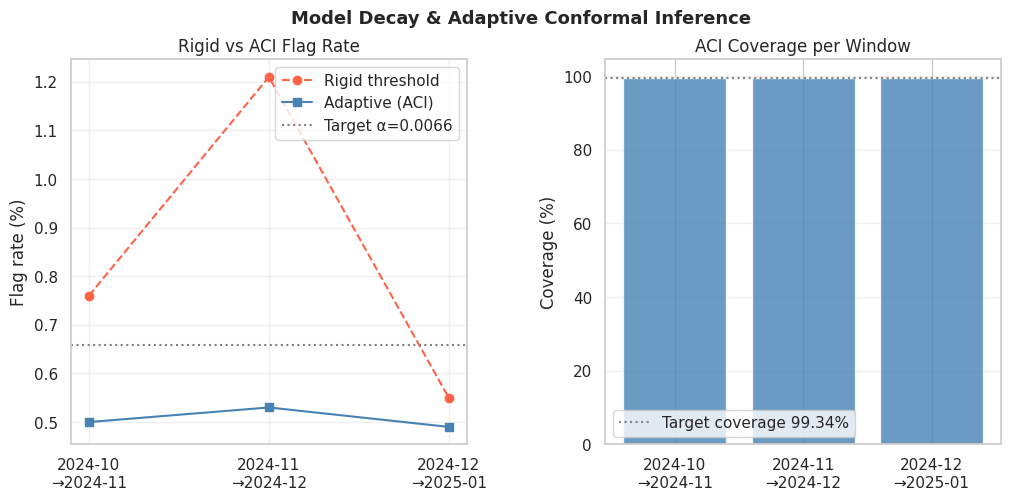

Saved: model_decay.png


In [ ]:
# ── Cell 109: Decay plot — rigid vs ACI ──────────────────────────────────────
%matplotlib inline


fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

windows = decay_df['window'].tolist()
x = range(len(windows))
labels = [f"{r['cal_month']}\n→{r['test_month']}" for _, r in decay_df.iterrows()]

# 1. Flag rate: rigid vs ACI
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, decay_df['flag_rate_rigid'] * 100, 'o--', color='tomato', label='Rigid threshold')
ax1.plot(x, decay_df['flag_rate_aci'] * 100, 's-', color='steelblue', label='Adaptive (ACI)')
ax1.axhline(ALPHA * 100, color='gray', linestyle=':', label=f'Target α={ALPHA:.4f}')
ax1.set_xticks(list(x)); ax1.set_xticklabels(labels)
ax1.set_ylabel('Flag rate (%)'); ax1.set_title('Rigid vs ACI Flag Rate')
ax1.legend(); ax1.grid(True, alpha=0.3)

# 2. ACI coverage per window
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(list(x), decay_df['aci_coverage'] * 100, color='steelblue', alpha=0.8)
ax2.axhline((1 - ALPHA) * 100, color='gray', linestyle=':', label=f'Target coverage {(1-ALPHA)*100:.2f}%')
ax2.set_xticks(list(x)); ax2.set_xticklabels(labels)
ax2.set_ylabel('Coverage (%)'); ax2.set_title('ACI Coverage per Window')
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Decay & Adaptive Conformal Inference', fontsize=13, fontweight='bold')
plt.savefig(CKPT + 'model_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_decay.png')

## External baselines: LOF, One-Class SVM, MLP Autoencoder


## Wallet-level comparison


## 2. Ablation: component contribution vs baseline


In [87]:
ALPHA = 0.0066

def conformal_flags(cal_scores, test_scores, alpha):
    threshold = np.quantile(cal_scores, 1 - alpha)
    pvals = np.array([
        (np.sum(cal_scores >= s) + 1) / (len(cal_scores) + 1)
        for s in test_scores
    ])
    flags = (pvals <= alpha).astype(int)
    return threshold, pvals, flags

val_mask_w  = wallet_scores['wallet'].isin(val_wallets).values
test_mask_w = wallet_scores['wallet'].isin(test_wallets).values

score_sets = {
    'baseline': wallet_scores['raw_score'].values,
    'if_only': wallet_scores['if_score'].values,
    'tr_only': wallet_scores['tr_score'].values,
}

_, _, baseline_test_flags = conformal_flags(
    score_sets['baseline'][val_mask_w],
    score_sets['baseline'][test_mask_w],
    ALPHA,
)

rows = []
for name, scores in score_sets.items():
    thr, pvals, flags = conformal_flags(scores[val_mask_w], scores[test_mask_w], ALPHA)

    inter = np.sum((flags == 1) & (baseline_test_flags == 1))
    union = np.sum((flags == 1) | (baseline_test_flags == 1))
    jaccard = inter / union if union > 0 else 1.0

    rows.append({
        'run': name,
        'threshold': float(thr),
        'flagged_wallets': int(flags.sum()),
        'flag_rate_pct': float(flags.mean() * 100),
        'jaccard_vs_baseline': float(jaccard),
    })

ablation_results = pd.DataFrame(rows)
base_rate = float(ablation_results.loc[ablation_results['run'] == 'baseline', 'flag_rate_pct'].iloc[0])
ablation_results['delta_rate_vs_baseline'] = ablation_results['flag_rate_pct'] - base_rate

print('Ablation results (wallet-level conformal flags):')
print(ablation_results.sort_values('run').to_string(index=False))

Ablation results (wallet-level conformal flags):
     run  threshold  flagged_wallets  flag_rate_pct  jaccard_vs_baseline  delta_rate_vs_baseline
baseline   0.965055             1305       0.755318             1.000000                0.000000
 if_only   0.960207             1321       0.764578             0.686577                0.009261
 tr_only   0.989918             1529       0.884966             0.212666                0.129648


In [41]:
# Compared to the baseline (IF + Transformer AE) via wallet-level Jaccard
# and rank correlation on the test set.  No labels required.


_wallet_arr = df_flat['wallet'].to_numpy() if hasattr(df_flat['wallet'], 'to_numpy') else np.array(df_flat['wallet'])

print('Fitting LOF ...')
_lof = LocalOutlierFactor(n_neighbors=20, contamination='auto',
                          novelty=True, n_jobs=-1)
_rng_lof = np.random.default_rng(42)
_lof_n = train_mask_tx.sum()
_lof_idx = _rng_lof.choice(_lof_n, size=min(25000, _lof_n), replace=False)
_lof.fit(X_tx_norm[train_mask_tx][_lof_idx])
_lof_raw        = -_lof.decision_function(X_tx_norm)
_lof_train_sort = np.sort(_lof_raw[train_mask_tx])
_lof_score      = np.searchsorted(_lof_train_sort, _lof_raw, side='right') / len(_lof_train_sort)

lof_wallet_score = (
    pd.DataFrame({'wallet': _wallet_arr, 'lof_score': _lof_score})
    .groupby('wallet')['lof_score'].max()
)

print('Fitting OCSVM (15 k train sample) ...')
_rng_oc  = np.random.default_rng(42)
_oc_n    = train_mask_tx.sum()
_oc_idx  = _rng_oc.choice(_oc_n, size=min(15000, _oc_n), replace=False)
_ocsvm   = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
_ocsvm.fit(X_tx_norm[train_mask_tx][_oc_idx])
_ocsvm_raw        = -_ocsvm.decision_function(X_tx_norm)
_ocsvm_train_sort = np.sort(_ocsvm_raw[train_mask_tx])
_ocsvm_score      = np.searchsorted(_ocsvm_train_sort, _ocsvm_raw, side='right') / len(_ocsvm_train_sort)

ocsvm_wallet_score = (
    pd.DataFrame({'wallet': _wallet_arr, 'ocsvm_score': _ocsvm_score})
    .groupby('wallet')['ocsvm_score'].max()
)

print('Fitting MLP AE ...')
class MlpAE(nn.Module):
    def __init__(self, n_feat, hidden=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(n_feat, hidden), nn.ReLU(),
                                 nn.Linear(hidden, 32),     nn.ReLU())
        self.dec = nn.Sequential(nn.Linear(32, hidden),     nn.ReLU(),
                                 nn.Linear(hidden, n_feat))
    def forward(self, x):
        return self.dec(self.enc(x))

_mlp = MlpAE(X_tx_norm.shape[1]).to(device)
_mlp_opt = torch.optim.Adam(_mlp.parameters(), lr=1e-3)
_mlp_dl  = DataLoader(TensorDataset(torch.from_numpy(X_tx_norm[train_mask_tx])),
                      batch_size=256, shuffle=True)
_mlp.train()
for _ep in range(6):
    _tot = 0
    for (_xb,) in _mlp_dl:
        _xb  = _xb.to(device)
        _l   = nn.functional.huber_loss(_mlp(_xb), _xb)
        _mlp_opt.zero_grad(); _l.backward(); _mlp_opt.step()
        _tot += _l.item()
    print(f'  MLP AE epoch {_ep+1}/6  loss={_tot/len(_mlp_dl):.6f}')

_mlp.eval()
_mlp_err = []
with torch.no_grad():
    for _i in range(0, len(X_tx_norm), 1024):
        _xb = torch.from_numpy(X_tx_norm[_i:_i+1024]).to(device)
        _err = nn.functional.huber_loss(_mlp(_xb), _xb, reduction='none').mean(dim=1).cpu().numpy()
        _mlp_err.append(_err)
_mlp_raw        = np.concatenate(_mlp_err)
_mlp_train_sort = np.sort(_mlp_raw[train_mask_tx])
_mlp_score      = np.searchsorted(_mlp_train_sort, _mlp_raw, side='right') / len(_mlp_train_sort)

mlp_wallet_score = (
    pd.DataFrame({'wallet': _wallet_arr, 'mlp_score': _mlp_score})
    .groupby('wallet')['mlp_score'].max()
)

_comp_ws = pl.from_pandas(wallet_scores[['wallet', 'raw_score']])
for _df_ext in [lof_wallet_score, ocsvm_wallet_score, mlp_wallet_score]:
    _comp_ws = _comp_ws.join(pl.from_pandas(_df_ext.reset_index()), on='wallet', how='left')
_comp_ws = _comp_ws.to_pandas().rename(columns={'raw_score': 'baseline'})

_val_m  = _comp_ws['wallet'].isin(val_wallets).values
_test_m = _comp_ws['wallet'].isin(test_wallets).values

_base_cal  = _comp_ws.loc[_val_m,  'baseline'].values
_base_test = _comp_ws.loc[_test_m, 'baseline'].values
_base_fl   = (_base_test >= np.quantile(_base_cal, 1 - ALPHA)).astype(int)

_ext_rows = []
for _det in ['baseline', 'lof_score', 'ocsvm_score', 'mlp_score']:
    _cal_s  = _comp_ws.loc[_val_m,  _det].fillna(0).values
    _test_s = _comp_ws.loc[_test_m, _det].fillna(0).values
    _fl     = (_test_s >= np.quantile(_cal_s, 1 - ALPHA)).astype(int)
    _inter  = int(np.sum((_fl == 1) & (_base_fl == 1)))
    _union  = int(np.sum((_fl == 1) | (_base_fl == 1)))
    _jac    = _inter / _union if _union > 0 else 1.0
    _rho    = float(spearmanr(_test_s, _base_test).correlation)
    _ext_rows.append({'detector': _det,
                      'flagged': int(_fl.sum()),
                      'flag_rate_pct': round(float(_fl.mean() * 100), 2),
                      'jaccard_vs_baseline': round(_jac, 4),
                      'rank_corr_vs_baseline': round(_rho, 4)})

external_baselines_df = pd.DataFrame(_ext_rows)
print('\nExternal baseline comparison (wallet-level):')
print(external_baselines_df.to_string(index=False))
print('\nInterpretation: high Jaccard/rank-corr with baseline → consistent signal;'
      ' low → detectors disagree on which wallets are anomalous.')


Fitting LOF ...
Fitting OCSVM (15 k train sample) ...
Fitting MLP AE ...
  MLP AE epoch 1/6  loss=0.003335
  MLP AE epoch 2/6  loss=0.000046
  MLP AE epoch 3/6  loss=0.000021
  MLP AE epoch 4/6  loss=0.000009
  MLP AE epoch 5/6  loss=0.000007
  MLP AE epoch 6/6  loss=0.000006

External baseline comparison (wallet-level):
   detector  flagged  flag_rate_pct  jaccard_vs_baseline  rank_corr_vs_baseline
   baseline     1321           0.76               1.0000                 1.0000
  lof_score     3242           1.88               0.0029                 0.1056
ocsvm_score     1170           0.68               0.2016                 0.5696
  mlp_score      901           0.52               0.1066                 0.6129

Interpretation: high Jaccard/rank-corr with baseline → consistent signal; low → detectors disagree on which wallets are anomalous.


In [44]:
# ── Model Comparison: Overlap and Detection Agreement ───────────────────────

# Define the anomaly threshold (e.g., alpha = 0.006, from Rigid ACI)
ALPHA = 0.0066

# 1. Calculate the empirical thresholds for each method
if_thr = wallet_scores['if_score'].quantile(1 - ALPHA)
tr_thr = wallet_scores['tr_score'].quantile(1 - ALPHA)
en_thr = wallet_scores['raw_score'].quantile(1 - ALPHA)

# 2. Identify flagged wallets for each method
if_anomalies = set(wallet_scores[wallet_scores['if_score'] >= if_thr]['wallet'])
tr_anomalies = set(wallet_scores[wallet_scores['tr_score'] >= tr_thr]['wallet'])
en_anomalies = set(wallet_scores[wallet_scores['raw_score'] >= en_thr]['wallet'])

total_wallets = len(wallet_scores)

# 3. Compute overlap and unique contributions
overlap_if_tr = if_anomalies.intersection(tr_anomalies)

en_in_if = en_anomalies.intersection(if_anomalies)
en_in_tr = en_anomalies.intersection(tr_anomalies)
en_in_both = en_in_if.intersection(en_in_tr)
en_unique = en_anomalies - if_anomalies - tr_anomalies

# 4. Generate comparison report
comparison_results = [
    {
        'Detector': 'Isolation Forest (IF)',
        'Threshold': round(if_thr, 4),
        'Flagged Wallets': len(if_anomalies),
        '% of Total': f"{(len(if_anomalies) / total_wallets) * 100:.2f}%"
    },
    {
        'Detector': 'Transformer AE (TR)',
        'Threshold': round(tr_thr, 4),
        'Flagged Wallets': len(tr_anomalies),
        '% of Total': f"{(len(tr_anomalies) / total_wallets) * 100:.2f}%"
    },
    {
        'Detector': 'Ensemble (MoA)',
        'Threshold': round(en_thr, 4),
        'Flagged Wallets': len(en_anomalies),
        '% of Total': f"{(len(en_anomalies) / total_wallets) * 100:.2f}%"
    }
]

print(f"--- Anomaly Detection Comparison (Top {ALPHA*100:.1f}%) ---")
print(pd.DataFrame(comparison_results).to_string(index=False))

print("\n--- Ensemble Agreement Analysis ---")
print(f"Total Ensemble Anomalies: {len(en_anomalies)}")
print(f"  ↳ Caught by IF too:     {len(en_in_if)} ({(len(en_in_if)/len(en_anomalies))*100:.1f}%)")
print(f"  ↳ Caught by TR too:     {len(en_in_tr)} ({(len(en_in_tr)/len(en_anomalies))*100:.1f}%)")
print(f"  ↳ Caught by BOTH:       {len(en_in_both)} ({(len(en_in_both)/len(en_anomalies))*100:.1f}%)")
print(f"  ↳ Unique to Ensemble:   {len(en_unique)} ({(len(en_unique)/len(en_anomalies))*100:.1f}%)")

--- Anomaly Detection Comparison (Top 0.7%) ---
             Detector  Threshold  Flagged Wallets % of Total
Isolation Forest (IF)     0.9684             4087      0.66%
  Transformer AE (TR)     0.9924             4089      0.66%
       Ensemble (MoA)     0.9686             4087      0.66%

--- Ensemble Agreement Analysis ---
Total Ensemble Anomalies: 4087
  ↳ Caught by IF too:     2522 (61.7%)
  ↳ Caught by TR too:     1736 (42.5%)
  ↳ Caught by BOTH:       997 (24.4%)
  ↳ Unique to Ensemble:   826 (20.2%)


## 3. Sensitivity: stability across hyperparameter ranges


In [45]:
w_if_grid = [0.30, 0.40, 0.50, 0.60, 0.70]
alpha_grid = [0.001, 0.0066, 0.005, 0.01, 0.02]

if_all = wallet_scores['if_score'].values
tr_all = wallet_scores['tr_score'].values

baseline_test_scores = score_sets['baseline'][test_mask_w]

sens_rows = []

for w_if in w_if_grid:
    w_tr = 1.0 - w_if
    mixed_scores = w_if * if_all + w_tr * tr_all

    for alpha in alpha_grid:
        _, _, flags = conformal_flags(mixed_scores[val_mask_w], mixed_scores[test_mask_w], alpha)

        inter = np.sum((flags == 1) & (baseline_test_flags == 1))
        union = np.sum((flags == 1) | (baseline_test_flags == 1))
        jaccard = inter / union if union > 0 else 1.0

        rho = spearmanr(mixed_scores[test_mask_w], baseline_test_scores).correlation
        if np.isnan(rho):
            rho = 0.0

        sens_rows.append({
            'w_if': float(w_if),
            'w_tr': float(w_tr),
            'alpha': float(alpha),
            'flag_rate_pct': float(flags.mean() * 100),
            'jaccard_vs_baseline': float(jaccard),
            'rank_corr_vs_baseline': float(rho),
        })

sensitivity_results = pd.DataFrame(sens_rows)
print('Sensitivity sweep:')
print(sensitivity_results.sort_values(['alpha', 'w_if']).to_string(index=False))

Sensitivity sweep:
 w_if  w_tr  alpha  flag_rate_pct  jaccard_vs_baseline  rank_corr_vs_baseline
  0.3   0.7 0.0010       0.154536             0.202273               0.997073
  0.4   0.6 0.0010       0.151064             0.197727               0.999086
  0.5   0.5 0.0010       0.143539             0.187879               1.000000
  0.6   0.4 0.0010       0.145276             0.190152               0.998310
  0.7   0.3 0.0010       0.148170             0.193939               0.989741
  0.3   0.7 0.0050       0.439300             0.538860               0.997073
  0.4   0.6 0.0050       0.475184             0.621970               0.999086
  0.5   0.5 0.0050       0.520330             0.681061               1.000000
  0.6   0.4 0.0050       0.627984             0.821970               0.998310
  0.7   0.3 0.0050       0.661554             0.783490               0.989741
  0.3   0.7 0.0066       0.571842             0.561570               0.997073
  0.4   0.6 0.0066       0.621618            

## 4. Contamination: baseline detection on synthetic anomalies


In [74]:
ae_model_optimised


WalletTransformerAE(
  (input_proj): Linear(in_features=21, out_features=32, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.005197439087261491, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.005197439087261491, inplace=False)
        (dropout2): Dropout(p=0.005197439087261491, inplace=False)
      )
    )
  )
  (out_proj): Linear(in_features=32, out_features=21, bias=True)
)

In [97]:
iforest

IsolationForest(max_samples=512, n_estimators=350, random_state=42)

In [69]:
X_tx_norm.shape

(2905990, 21)

In [103]:

def run_synthetic_contamination_test(n_target_wallets=1500, min_test_tx=2, alpha=0.001,  w_if=0.5, w_tr=0.5):
    """
    Runs a synthetic contamination test to measure pipeline recall (TPR).

    Args:
        n_target_wallets (int): Number of wallets to contaminate.
        min_test_tx (int): Minimum test transactions required for a wallet to be eligible.
        alpha (float): Quantile threshold for the anomaly flag.
        w_if (float): Ensemble weight for Isolation Forest.
        w_tr (float): Ensemble weight for Transformer AE.
    """
    # 1. Initialise scaler_reduced and the filtered training mask
    scaler_reduced = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
    train_mask_tx_filtered = train_mask_tx.copy()

    # Fit on the training portion of the filtered features
    scaler_reduced.fit(X_tx[train_mask_tx_filtered])

    # Create modifiable normalized matrix
    X_norm_mod = X_tx_norm_filtered.copy()

    print("--- Initialising Clean Contamination Test ---")

    rng = np.random.default_rng(42)
    feat_idx = {f: i for i, f in enumerate(tx_feature_cols)}
    w_arr = df_flat['wallet'].to_numpy() if hasattr(df_flat, 'with_columns') else df_flat['wallet'].values

    # ── 1. Target Selection (Heavy Wallets) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # identify valid test transactions in the bottom 50% (Normal baseline)
    valid_mask = np.zeros(len(w_arr), dtype=bool)
    for w, (start, total) in WALLET_INDEX.items():
        valid_mask[start + (total - min(total, MAX_SEQ_LEN)) : start + total] = True

    # Recover scores from untruncated sources to define the normal baseline
    if 'ensemble_wallet' in globals() and 'all_wallets' in globals():
        wallet_score_map = dict(zip(all_wallets, ensemble_wallet))
        tx_scores = np.array([wallet_score_map.get(w, 0.0) for w in w_arr])
    elif 'wallet_scores_all' in globals():
        wallet_score_map = dict(zip(wallet_scores_all['wallet'], wallet_scores_all['raw_score']))
        tx_scores = np.array([wallet_score_map.get(w, 0.0) for w in w_arr])
    else:
        tx_scores = np.zeros(len(w_arr))

    normal_mask = test_mask_tx & valid_mask & (tx_scores <= np.quantile(tx_scores[test_mask_tx], 0.50))
    normal_tx_indices = np.where(normal_mask)[0]
    if len(normal_tx_indices) == 0: normal_tx_indices = np.where(test_mask_tx & valid_mask)[0]

    # Filter for wallets with >= min_test_tx test transactions
    unique_w, counts = np.unique(w_arr[test_mask_tx & valid_mask], return_counts=True)
    heavy_wallets = unique_w[counts >= min_test_tx]
    valid_pool = np.intersect1d(np.unique(w_arr[normal_tx_indices]), heavy_wallets)

    if len(valid_pool) == 0:
        print("Fallback: Using all valid test wallets.")
        valid_pool = np.unique(w_arr[normal_tx_indices])

    chosen_wallets = rng.choice(valid_pool, size=min(n_target_wallets, len(valid_pool)), replace=False)

    # Gather all test transactions for chosen wallets
    syn_pick = []
    for w in chosen_wallets:
        start, total = WALLET_INDEX[w]
        row_start = start + (total - min(total, MAX_SEQ_LEN))
        syn_pick.extend([idx for idx in range(row_start, start + total) if test_mask_tx[idx]])

    syn_pick = np.array(syn_pick)
    n_syn = len(syn_pick)
    syn_wallets = sorted(set(w_arr[syn_pick].tolist()))

    print(f'Contaminating {n_syn} TXs across {len(syn_wallets)} wallets (Ratio: {n_syn/len(syn_wallets):.1f})')

    # ── 2. Anomaly Injection ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    X_syn_raw = X_tx[syn_pick].copy()

    anomaly_specs = {
        'fee_sol': (3.0, 8.0), 'compute_units_consumed': (2.0, 5.0),
        'instigator_sol_delta': (5.0, 15.0), 'inner_instruction_count': (3.0, 6.0),
    }

    for f, (lo, hi) in anomaly_specs.items():
        if f in feat_idx:
            X_syn_raw[:, feat_idx[f]] *= rng.uniform(lo, hi, size=n_syn)
    if 'success_flag' in feat_idx:
        X_syn_raw[:, feat_idx['success_flag']] = 0.0

    train_ref = X_tx[train_mask_tx_filtered]
    X_syn_raw += rng.normal(0.0, 0.3 * (train_ref.std(axis=0) + 1e-6), size=X_syn_raw.shape)

    # ── 3. Score: Isolation Forest (Spatial) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    X_tx_mod = X_tx.copy()
    X_tx_mod[syn_pick] = X_syn_raw
    if_raw_mod = -iforest.decision_function(X_tx_mod)

    if 'if_train_sort' in globals():
        _ref_sort = if_train_sort
    else:
        _ref_sort = np.sort(-iforest.decision_function(X_tx[train_mask_tx_filtered]))

    if_cdf_mod = np.searchsorted(_ref_sort, if_raw_mod, side='right') / len(_ref_sort)
    del X_tx_mod

    # ── 4. Score: Transformer AE (Temporal) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    syn_norm = scaler_reduced.transform(X_syn_raw).astype(np.float32)

    X_norm_mod[syn_pick] = syn_norm
    model_active = ae_model_optimised if 'ae_model_optimised' in globals() else tr_model

    contam_wallet_raw, _ = score_wallet_ae(
        model_active, X_norm_mod, WALLET_INDEX, syn_wallets, MAX_SEQ_LEN, device, tx_feature_cols
    )

    if 'ae_scores' in globals():
        ae_train_sort = np.sort(ae_scores[train_w_mask])
    else:
        ae_train_sort = np.sort(contam_wallet_raw)
    contam_wallet_cdf = np.searchsorted(ae_train_sort, contam_wallet_raw, side='right') / len(ae_train_sort)

    # ── 5. Max of Averages (MoA) Ensemble ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    wallet_ensemble_mod = {}
    for i, w in enumerate(syn_wallets):
        wallet_if_max = float(if_cdf_mod[w_arr == w].max())
        wallet_ae_score = float(contam_wallet_cdf[i])
        wallet_ensemble_mod[w] = (w_if * wallet_if_max) + (w_tr * wallet_ae_score)

    # ── 6. Evaluation against Pipeline Thresholds ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    if 'wallet_scores' in globals() and 'raw_score' in wallet_scores.columns:
        en_thr = np.quantile(wallet_scores['raw_score'], 1 - alpha)
    elif 'ensemble_wallet' in globals() and 'val_w_mask' in globals():
        en_thr = np.quantile(ensemble_wallet[val_w_mask], 1 - alpha)
    else:
        en_thr = 0.95  # Absolute fallback

    en_det = sum(1 for s in wallet_ensemble_mod.values() if s >= en_thr)

    print(f'\n=== CONTAMINATED DATA RESULTS ===')
    print(f"Target: Detect extreme synthetic exploits.")
    print(f"Alpha (Threshold): {alpha}")
    print(f"Weights: IF={w_if}, TR={w_tr}")
    print(f"Ensemble Threshold (from clean validation): {en_thr:.4f}")
    print(f"Detection Rate: {en_det}/{len(syn_wallets)} wallets ({en_det/len(syn_wallets)*100:.2f}%)")

print('\n>> RUNNING: RIGID CI Parameters (Alpha=0.0066, Weights=0.5/0.5)')
run_synthetic_contamination_test(n_target_wallets=1500, min_test_tx=2, alpha=0.006, w_if=0.5, w_tr=0.5)

print('\n>> RUNNING: Default Parameters (Alpha=0.001, Weights=0.5/0.5)')
run_synthetic_contamination_test(n_target_wallets=1500, min_test_tx=2, alpha=0.001, w_if=0.5, w_tr=0.5)

print('\n>> RUNNING: High Alpha (Alpha=0.01, min_test_tx=2)')
run_synthetic_contamination_test(min_test_tx=2, alpha=0.01)

print('\n>> RUNNING: Denser Transactions (Alpha=0.001, min_test_tx=3)')
run_synthetic_contamination_test(min_test_tx=3, alpha=0.001)

print('\n>> RUNNING: High Alpha + Denser (Alpha=0.01, min_test_tx=3)')
run_synthetic_contamination_test(min_test_tx=3, alpha=0.01)

print('\n>> RUNNING: IF-Dominant Weights (Alpha=0.001, IF=0.7, TR=0.3)')
run_synthetic_contamination_test(n_target_wallets=1500, min_test_tx=2, alpha=0.001, w_if=0.7, w_tr=0.3)

print('\n>> RUNNING: TR-Dominant Weights (Alpha=0.001, IF=0.3, TR=0.7)')
run_synthetic_contamination_test(n_target_wallets=1500, min_test_tx=2, alpha=0.001, w_if=0.3, w_tr=0.7)

print('\n>> RUNNING: TR-Dominant Weights CI (Alpha=0.0066, IF=0.3, TR=0.7)')
run_synthetic_contamination_test(n_target_wallets=1500, min_test_tx=2, alpha=0.0066, w_if=0.3, w_tr=0.7)

print('\n>> RUNNING: IF-Dominant Weights CI (Alpha=0.0066, IF=0.7, TR=0.3)')
run_synthetic_contamination_test(n_target_wallets=1500, min_test_tx=2, alpha=0.0066, w_if=0.3, w_tr=0.7)




>> RUNNING: RIGID CI Parameters (Alpha=0.0066, Weights=0.5/0.5)
--- Initialising Clean Contamination Test ---
Contaminating 12798 TXs across 1500 wallets (Ratio: 8.5)
Pre-computing and caching 1500 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True

=== CONTAMINATED DATA RESULTS ===
Target: Detect extreme synthetic exploits.
Alpha (Threshold): 0.006
Weights: IF=0.5, TR=0.5
Ensemble Threshold (from clean validation): 0.9702
Detection Rate: 1465/1500 wallets (97.67%)

>> RUNNING: Default Parameters (Alpha=0.001, Weights=0.5/0.5)
--- Initialising Clean Contamination Test ---
Contaminating 12798 TXs across 1500 wallets (Ratio: 8.5)
Pre-computing and caching 1500 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True

=== CONTAMINATED DATA RESULTS ===
Target: Detect extreme synthetic exploits.
Alpha (Threshold): 0.001
Weights: IF=0.5, TR=0.

## Heatmap: flagged wallets × top features


In [99]:

# Assuming necessary globals are available in your environment:
# df_flat, wallet_scores, test_wallets, val_wallets, ALPHA, if_tx_score, tr_tx_score
# WALLET_INDEX, MAX_SEQ_LEN, X_tx_norm, tx_feature_cols, ae_model_optimised, tr_model, device

# 1. ATTACH SCORES TO DF_FLAT: Fixes ColumnNotFoundError
# We must ensure the transaction-level scores are sitting in df_flat for the .agg lookup
if 'if_tx_score' in globals():
    if hasattr(df_flat, 'with_columns'):
        if 'if_tx_score' not in df_flat.columns:
            df_flat = df_flat.with_columns(pl.Series("if_tx_score", if_tx_score))
    else:
        df_flat['if_tx_score'] = if_tx_score

if 'tr_tx_score' in globals():
    if hasattr(df_flat, 'with_columns'):
        if 'tr_tx_score' not in df_flat.columns:
            df_flat = df_flat.with_columns(pl.Series("tr_tx_score", tr_tx_score))
    else:
        df_flat['tr_tx_score'] = tr_tx_score

# 2. Identify top 20 flagged test wallets
# Prioritise conformal_flag, fallback to raw_score quantile if missing
flagged = wallet_scores[
  wallet_scores['wallet'].isin(test_wallets) &
  (wallet_scores['conformal_flag'].fillna(0).astype(int) == 1 if 'conformal_flag' in wallet_scores.columns else wallet_scores['raw_score'] >= np.quantile(wallet_scores['raw_score'], 1 - ALPHA))
].sort_values('raw_score', ascending=False).head(20).copy()

if len(flagged) == 0:
  print('No flagged test wallets at current alpha.')
else:
  # Use tr_tx_score if available for pinpointing the "moment" of anomaly
  _tr_col = 'tr_tx_score' if 'tr_tx_score' in df_flat.columns else 'if_tx_score'

  # 3. FAST TOP-TX LOOKUP: Find the exact index of the worst transaction per wallet
  if hasattr(df_flat, 'with_columns'):
      # Polars optimised version
      df_flat_with_idx = df_flat.with_row_index("original_idx")
      tx_top_idx_df = df_flat_with_idx.group_by("wallet").agg(
          pl.col("original_idx").filter(pl.col(_tr_col) == pl.col(_tr_col).max()).first().alias("tx_idx")
      )
      tx_top_idx = tx_top_idx_df.to_pandas().set_index('wallet')['tx_idx']
  else:
      tx_top_idx = df_flat.groupby('wallet')[_tr_col].idxmax()

  feat_matrix, labels, rows = [], [], []
  model_to_use = ae_model_optimised if 'ae_model_optimised' in globals() else tr_model
  model_to_use.eval()

  # Calibration scores for reconstruction of p-values if missing
  cal_scores = wallet_scores.loc[wallet_scores['wallet'].isin(val_wallets), 'raw_score'].values
  sorted_cal = np.sort(cal_scores)

  for _, row in flagged.iterrows():
      w = row['wallet']
      tx_idx = tx_top_idx.get(w)
      if pd.isna(tx_idx): continue
      tx_idx = int(tx_idx)

      # 4. SEQUENCE MAPPING: Find the position of this TX inside the Transformer's 64-token window
      start, total = WALLET_INDEX[w]
      T_actual = min(total, MAX_SEQ_LEN)
      row_start = start + (total - T_actual)
      seq_idx = max(0, MAX_SEQ_LEN - T_actual + (tx_idx - row_start))

      # Reconstruct the sequence for this specific wallet
      seq_np = X_tx_norm[row_start : row_start + T_actual]
      seq = np.zeros((1, MAX_SEQ_LEN, len(tx_feature_cols)), dtype=np.float32)
      mask = np.ones((1, MAX_SEQ_LEN), dtype=bool)
      seq[0, -T_actual:] = seq_np
      mask[0, -T_actual:] = False

      seq_t = torch.tensor(seq, dtype=torch.float32).to(device)
      mask_t = torch.tensor(mask, dtype=torch.bool).to(device)

      with torch.no_grad():
          pred = model_to_use(seq_t, src_key_padding_mask=mask_t)
          # Calculate feature-level Huber error WITHOUT averaging the feature dimension
          err = F.huber_loss(pred, seq_t, reduction='none', delta=1.0)
          feat_err = err[0, min(seq_idx, MAX_SEQ_LEN-1)].cpu().numpy()

      topk_idx = np.argsort(feat_err)[-5:][::-1]
      dominant = 'IF' if row['if_score'] >= row['tr_score'] else 'AE'

      # 5. HIGH-PRECISION P-VALUE: Using scientific notation to avoid "0.0" rounding
      if 'conformal_p' in row and pd.notna(row.get('conformal_p')):
          cp = float(row['conformal_p'])
      else:
          # Standard conformal p-value formula: (count(cal >= score) + 1) / (N + 1)
          cp = (len(sorted_cal) - np.searchsorted(sorted_cal, row['raw_score'], side='left') + 1) / (len(sorted_cal) + 1)

      feat_matrix.append(feat_err)
      labels.append(f"{w[:8]}… p={cp:.1e}") # Use scientific notation
      rows.append({
          'wallet': w[:12] + '…',
          'raw_score': round(float(row['raw_score']), 4),
          'conformal_p': f"{cp:.2e}", # High precision string for table
          'dominant': dominant,
          'top_features': ', '.join(tx_feature_cols[i] for i in topk_idx)
      })

  # 6. REPORTING
  print("\n--- Top 20 Most Anomalous Wallets (Interpretability) ---")
  print(pd.DataFrame(rows).to_string(index=False))

  feat_mat = np.array(feat_matrix)
  # Show top 15 features contributing to anomaly scores globally
  top_feat_idx = np.argsort(feat_mat.mean(axis=0))[-15:]
  feat_mat_top = feat_mat[:, top_feat_idx]
  feat_names_top = [tx_feature_cols[i] for i in top_feat_idx]

  # 7. VISUALISATION
  fig, ax = plt.subplots(figsize=(14, max(4, len(labels) * 0.5)))
  sns.heatmap(feat_mat_top, annot=False, cmap='YlOrRd', xticklabels=feat_names_top, yticklabels=labels, linewidths=0.3, ax=ax)
  ax.set_title('Transformer Reconstruction Error by Feature', fontweight='bold')
  ax.set_xlabel('Feature')
  ax.set_ylabel('Wallet ID [p-value]')
  plt.tight_layout()

  save_path = 'interpretability_heatmap.png'
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
  plt.show()
  print(f'Saved: {save_path}')


--- Top 20 Most Anomalous Wallets (Interpretability) ---
       wallet  raw_score conformal_p dominant                                                                                                     top_features
A7fhLJaYmpov…     0.9999    6.58e-06       IF   instigator_sol_delta, num_balance_changes, involves_sysvar_flag, avg_depth_per_protocol, unknown_program_count
45q8atWAv8RE…     0.9999    6.58e-06       IF   instigator_sol_delta, num_balance_changes, involves_sysvar_flag, avg_depth_per_protocol, unknown_program_count
5ViMmBH96Nf3…     0.9998    1.32e-05       AE num_balance_changes, instigator_sol_delta, involves_sysvar_flag, inner_instruction_count, avg_depth_per_protocol
AGgUVH68jcsH…     0.9997    1.32e-05       IF           instigator_sol_delta, involves_sysvar_flag, num_balance_changes, unknown_program_count, has_sol_profit
CDBPmrLjrw2S…     0.9996    1.32e-05       AE         num_balance_changes, instigator_sol_delta, avg_depth_per_protocol, has_sol_profit, unknown_pr

## SHAP interpretability (Isolation Forest component)


In [30]:
shap_global_df = pd.DataFrame()
shap_local_top_df = pd.DataFrame()

try:
    import shap
except ImportError:
  print('SHAP is not installed in this environment. Run `pip install shap` and re-run this cell.')
else:
  required_vars = ['iforest', 'if_tx_score', 'X_tx', 'test_mask_tx', 'tx_feature_cols', 'df_flat']
  missing_vars = [v for v in required_vars if v not in globals()]
  if missing_vars:
      raise RuntimeError(f'Missing prerequisites for SHAP: {missing_vars}')

  bg_n = int(min(2000, np.sum(train_mask_tx))) if 'train_mask_tx' in globals() else int(min(2000, len(X_tx)))
  ex_n = int(min(300, np.sum(test_mask_tx)))
  if ex_n <= 0:
      raise RuntimeError('No test transactions available for SHAP interpretation.')

  # Define explain_idx: top anomalous transactions in the test set
  test_indices = np.where(test_mask_tx)[0]
  sorted_test_indices = test_indices[np.argsort(if_tx_score[test_indices])[::-1]]
  explain_idx = sorted_test_indices[:ex_n]

  rng_shap = np.random.default_rng(42)
  if 'train_mask_tx' in globals() and np.sum(train_mask_tx) > 0:
      train_idx = np.where(train_mask_tx)[0]
  else:
      train_idx = np.arange(len(X_tx))
  bg_idx = rng_shap.choice(train_idx, size=bg_n, replace=False) if len(train_idx) > bg_n else train_idx
  X_bg = X_tx[bg_idx].astype(np.float32)
  X_ex = X_tx[explain_idx].astype(np.float32)

  shap_values = None
  shap_mode = 'tree'

  try:
      explainer = shap.TreeExplainer(iforest)
      shap_values = explainer.shap_values(X_ex)
      if isinstance(shap_values, list):
          shap_values = shap_values[0]
      shap_values = np.asarray(shap_values, dtype=float)
  except Exception:
      shap_mode = 'model_agnostic'

      def _if_anom(x):
          x = np.asarray(x, dtype=np.float32)
          return -iforest.decision_function(x)

      explainer = shap.Explainer(_if_anom, X_bg, feature_names=tx_feature_cols)
      shap_out = explainer(X_ex)
      shap_values = np.asarray(shap_out.values, dtype=float)

  if shap_values.ndim != 2 or shap_values.shape[1] != len(tx_feature_cols):
      raise RuntimeError(f'Unexpected SHAP output shape: {shap_values.shape}')

  # Global IF feature importance
  mean_abs = np.mean(np.abs(shap_values), axis=0)
  shap_global_df = (
      pd.DataFrame({'feature': tx_feature_cols, 'mean_abs_shap': mean_abs})
      .sort_values('mean_abs_shap', ascending=False)
      .reset_index(drop=True)
  )

  print(f'SHAP mode: {shap_mode}')
  print('Top IF feature drivers by mean |SHAP|:')
  print(shap_global_df.head(15).to_string(index=False))

  # Local explanations for top anomalous transactions
  top_feat = shap_global_df.head(12)['feature'].tolist()
  top_feat_idx = [tx_feature_cols.index(f) for f in top_feat]

  shap_local_top_df = pd.DataFrame(
      shap_values[:, top_feat_idx],
      columns=top_feat,
  )
  shap_local_top_df['tx_idx'] = explain_idx

  # Handle both Polars and Pandas DataFrames for row extraction robustly
  try:
      shap_local_top_df['wallet'] = np.array(df_flat['wallet'])[explain_idx].astype(str)
  except Exception as e:
      print(f"Warning mapping wallets: {e}")
      shap_local_top_df['wallet'] = [f"tx_{i}" for i in explain_idx]

  shap_local_top_df['if_score'] = if_tx_score[explain_idx]

  # Seaborn visualisations
  fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

  sns.barplot(data=shap_global_df.head(15), x='mean_abs_shap', y='feature', color='#4C78A8', ax=axes[0])
  axes[0].set_title('SHAP global importance (Isolation Forest)')
  axes[0].set_xlabel('Mean |SHAP value|')
  axes[0].set_ylabel('Feature')

  hm_n = int(min(20, len(shap_local_top_df)))
  hm = shap_local_top_df[top_feat].head(hm_n).to_numpy(dtype=float)
  row_labels = []
  for w in shap_local_top_df['wallet'].head(hm_n):
      ws = str(w)
      row_labels.append(ws if len(ws) <= 14 else f'{ws[:6]}...{ws[-4:]}')

  sns.heatmap(
      hm,
      cmap='coolwarm',
      center=0.0,
      xticklabels=top_feat,
      yticklabels=row_labels,
      cbar_kws={'label': 'SHAP value'},
      ax=axes[1],
  )
  axes[1].set_title('Local SHAP (top anomalous test transactions)')
  axes[1].set_xlabel('Feature')
  axes[1].set_ylabel('Transaction (wallet)')
  axes[1].tick_params(axis='x', rotation=45)

  plt.tight_layout()

  save_dir = CKPT
  if not os.path.exists(save_dir):
      save_dir = '.'  # fallback if not in vastai

  plt.savefig(os.path.join(save_dir, 'shap_heatmap.png'), dpi=150, bbox_inches='tight')
  plt.show()

  if 'no_label_dashboard' in globals():
      no_label_dashboard['if_shap_global'] = shap_global_df
      no_label_dashboard['if_shap_local_top'] = shap_local_top_df

print('Saved SHAP outputs: `shap_global_df`, `shap_local_top_df` (and dashboard keys if available).')

SHAP mode: tree
Top IF feature drivers by mean |SHAP|:
                    feature  mean_abs_shap
             has_sol_profit       1.392299
             max_sol_change       1.380368
       involves_sysvar_flag       1.331120
      unknown_program_count       0.938665
instigator_net_token_profit       0.883181
       unique_program_count       0.790113
    inner_instruction_count       0.725421
        num_balance_changes       0.696122
     compute_units_consumed       0.559941
       instigator_sol_delta       0.422645
              max_cpi_depth       0.389724
             mint_diversity       0.386838
     avg_depth_per_protocol       0.288767
           has_token_profit       0.275101
              dex_hop_count       0.266219
Saved SHAP outputs: `shap_global_df`, `shap_local_top_df` (and dashboard keys if available).


In [31]:
ae_model_optimised

WalletTransformerAE(
  (input_proj): Linear(in_features=21, out_features=32, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.005197439087261491, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.005197439087261491, inplace=False)
        (dropout2): Dropout(p=0.005197439087261491, inplace=False)
      )
    )
  )
  (out_proj): Linear(in_features=32, out_features=21, bias=True)
)

## Seaborn heatmap


In [101]:
def _clean(x):
  x = np.asarray(x, dtype=float)
  return x[np.isfinite(x)]

def _drift_ks(ref, cur):
  r, c = _clean(ref), _clean(cur)
  if len(r) == 0 or len(c) == 0: return np.nan
  return float(ks_2samp(r, c).statistic)

_val_m  = wallet_scores['wallet'].isin(val_wallets).values
_test_m = wallet_scores['wallet'].isin(test_wallets).values

model_score_map = {
  'baseline': wallet_scores['raw_score'].to_numpy(dtype=float),
  'if_only':  wallet_scores['if_score'].to_numpy(dtype=float),
  'tr_only':  wallet_scores['tr_score'].to_numpy(dtype=float),
}
if '_comp_ws' in globals() and isinstance(_comp_ws, pd.DataFrame):
  for col in ['lof_score', 'ocsvm_score', 'mlp_score']:
      if col in _comp_ws.columns:
          model_score_map[col.replace('_score', '')] = (
              _comp_ws[['wallet', col]].drop_duplicates('wallet')
              .set_index('wallet').reindex(wallet_scores['wallet'])
              [col].fillna(0.0).to_numpy(dtype=float)
          )

_base_val  = _clean(model_score_map['baseline'][_val_m])
_base_test = _clean(model_score_map['baseline'][_test_m])
_base_thr  = float(np.quantile(_base_val, 1 - ALPHA))
_base_fl   = (_base_test >= _base_thr).astype(int)

rows = []
for det, arr in model_score_map.items():
  vs = _clean(arr[_val_m]); ts = _clean(arr[_test_m])
  if not len(vs) or not len(ts): continue
  thr = float(np.quantile(vs, 1 - ALPHA))
  fl  = (ts >= thr).astype(int)
  inter = int(np.sum((fl == 1) & (_base_fl == 1)))
  union = int(np.sum((fl == 1) | (_base_fl == 1)))
  rows.append({
      'detector':        det,
      'flag_rate_%':     round(fl.mean() * 100, 2),
      'tail_contrast':   round(float(np.quantile(ts, 0.99) - np.quantile(ts, 0.50)), 4),
      'jaccard_base':    round(inter / union, 4) if union else 1.0,
      'rank_corr_base':  round(float(spearmanr(ts, _base_test).correlation), 4),
      'ks_val_test':     round(_drift_ks(vs, ts), 4),
  })

model_error_metrics = pd.DataFrame(rows)
_ord = {'baseline': 0, 'if_only': 1, 'tr_only': 2, 'lof': 3, 'ocsvm': 4, 'mlp': 5}
model_error_metrics = model_error_metrics.iloc[
  model_error_metrics['detector'].map(_ord).fillna(99).argsort()
].reset_index(drop=True)

_plot = model_error_metrics.set_index('detector')
_norm = (_plot - _plot.min()) / (_plot.max() - _plot.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, max(3, len(_plot) * 0.7)))
sns.heatmap(
  _norm, annot=_plot.round(3), fmt='g',
  cmap='RdYlGn_r', linewidths=0.5, linecolor='white',
  cbar_kws={'label': 'Normalised (0=best, 1=worst)'},
  ax=ax,
)
ax.set_title('Model Error Metrics — No-Label Evaluation', fontsize=13, fontweight='bold')
ax.set_ylabel(''); ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(CKPT+'.model_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(model_error_metrics.to_string(index=False))

detector  flag_rate_%  tail_contrast  jaccard_base  rank_corr_base  ks_val_test
baseline         0.76         0.5018        1.0000          1.0000       0.0473
 if_only         0.76         0.5392        0.6857          0.7012       0.0629
 tr_only         0.89         0.4685        0.2140          0.9886       0.0539
     lof         1.88         0.1012        0.0029          0.1056       0.1243
   ocsvm         0.68         0.5733        0.2030          0.5692       0.1097
     mlp         0.52         0.8615        0.1073          0.6137       0.0768


## Summary table


In [ ]:
"""
# Covers: CP validity + p-value sharpness | AE HUB | IF separation | Jaccard stability

eval_rows = []

# Guarantee: realized false-alarm rate <= alpha on held-out normal (val) wallets.
if 'conformal_p' in wallet_scores.columns:
    _cp_val  = wallet_scores.loc[wallet_scores['wallet'].isin(val_wallets),  'conformal_p'].dropna().values
    _cp_test = wallet_scores.loc[wallet_scores['wallet'].isin(test_wallets), 'conformal_p'].dropna().values
else:
    _cp_val = np.array([])
    _cp_test = np.array([])
    print('\nCP Empirical Validity skipped: conformal_p not in wallet_scores (run conformal flags cell first).')

if len(_cp_val) > 0:
  print('── CP Empirical Validity (realized false-alarm rate vs target α) ──')
  print(f'  {"α_target":>10} {"α_realized":>12} {"gap_pp":>10} {"valid?":>8}')
  for a in [0.005, 0.01, 0.02, 0.05]:
    realized = float(np.mean(_cp_val <= a)) if len(_cp_val) else np.nan
    gap = abs(realized - a) * 100 if np.isfinite(realized) else np.nan
    valid = '✓' if np.isfinite(gap) and gap < 1.0 else '✗'
    print(f'  {a:>10.3f} {realized:>12.4f} {gap:>9.2f}% {valid:>8}')
    eval_rows.append({'metric': f'CP_validity_alpha={a}', 'value': round(realized, 4) if np.isfinite(realized) else np.nan})

if len(_cp_test) > 0:
  _hist, _ = np.histogram(_cp_test, bins=20, range=(0, 1), density=True)
  _hist = np.clip(_hist, 1e-9, None)
  _pval_entropy = float(scipy_entropy(_hist / _hist.sum()))
  _pval_low = float(np.mean(_cp_test < ALPHA))
  print(f'\n── P-value sharpness ──')
  print(f'  p-value entropy (lower=sharper): {_pval_entropy:.4f}')
  print(f'  fraction with p < α={ALPHA}:     {_pval_low:.4f}')
  eval_rows.append({'metric': 'pval_entropy',           'value': round(_pval_entropy, 4)})
  eval_rows.append({'metric': 'pval_flagged_at_alpha',  'value': round(_pval_low, 4)})

if 'tr_wallet_raw' in globals() or 'ae_scores' in globals():
  _ae_raw = ae_scores if 'ae_scores' in globals() else tr_wallet_raw
  _test_w_mask = np.isin(all_wallets, list(test_wallets))
  _train_w_mask = np.isin(all_wallets, list(train_wallets))

  _ae_hub_test  = float(np.mean(_ae_raw[_test_w_mask]))
  _ae_hub_train = float(np.mean(_ae_raw[_train_w_mask]))
  _ae_ratio     = _ae_hub_test / max(_ae_hub_train, 1e-12)
  print(f'\n── AE Reconstruction HUB ──')
  print(f'  Train HUB : {_ae_hub_train:.6f}')
  print(f'  Test  HUB : {_ae_hub_test:.6f}')
  print(f'  Test/Train ratio (≈1 = no overfit): {_ae_ratio:.4f}')
  eval_rows.append({'metric': 'ae_hub_train',      'value': round(_ae_hub_train, 6)})
  eval_rows.append({'metric': 'ae_hub_test',       'value': round(_ae_hub_test,  6)})
  eval_rows.append({'metric': 'ae_hub_test/train', 'value': round(_ae_ratio,     4)})
else:
  print('\nAE HUB skipped: tr_wallet_raw not in scope (run AE scoring cell first).')

if 'model_error_metrics' in globals() and len(model_error_metrics):
  _base_row = model_error_metrics[model_error_metrics['detector'] == 'baseline']
  if len(_base_row):
      _tc = float(_base_row['tail_contrast'].values[0])
      _ks = float(_base_row['ks_val_test'].values[0])
      print(f'\n── IF Score Separation (MV/EM proxy) ──')
      print(f'  Tail contrast  (p99-p50) : {_tc:.4f}  [higher = better separation]')
      print(f'  KS stat val→test         : {_ks:.4f}  [lower = more stable]')
      eval_rows.append({'metric': 'if_tail_contrast', 'value': round(_tc, 4)})
      eval_rows.append({'metric': 'if_ks_val_test',   'value': round(_ks, 4)})

if 'struct_perm_df' in globals() and struct_perm_df is not None and len(struct_perm_df):
  _jac_mean = float(struct_perm_df['jaccard_vs_original_flags'].mean())
  _jac_std  = float(struct_perm_df['jaccard_vs_original_flags'].std())
  print(f'\n── Jaccard Subsample Stability ──')
  print(f'  Mean Jaccard : {_jac_mean:.4f} ± {_jac_std:.4f}')
  print(f'  n_runs       : {len(struct_perm_df)}')
  eval_rows.append({'metric': 'jaccard_stability_mean', 'value': round(_jac_mean, 4)})
  eval_rows.append({'metric': 'jaccard_stability_std',  'value': round(_jac_std,  4)})
else:
  print('\nJaccard stability skipped: run permutation cell first.')

eval_summary = pd.DataFrame(eval_rows)
print('\n── Evaluation Summary ──')
print(eval_summary.to_string(index=False))
"""


── P-value sharpness ──
  p-value entropy (lower=sharper): 2.9814
  fraction with p < α=0.001:     0.0014

── AE Reconstruction HUB ──
  Train HUB : 0.020360
  Test  HUB : 0.019911
  Test/Train ratio (≈1 = no overfit): 0.9780

── IF Score Separation (MV/EM proxy) ──
  Tail contrast  (p99-p50) : 0.5015  [higher = better separation]
  KS stat val→test         : 0.0464  [lower = more stable]

Jaccard stability skipped: run permutation cell first.

── Evaluation Summary ──
               metric    value
         pval_entropy 2.981400
pval_flagged_at_alpha 0.001400
         ae_hub_train 0.020360
          ae_hub_test 0.019911
    ae_hub_test/train 0.978000
     if_tail_contrast 0.501500
       if_ks_val_test 0.046400




```
## References
```



In [ ]:
## Libraries Used

- `numpy` (as `np`): Numerical computing library.
- `pandas` (as `pd`): Data manipulation and analysis library.
- `polars` (as `pl`): High-performance DataFrame library. [Polars Website](https://www.pola.rs/)
- `polars.selectors` (as `cs`): Utility for selecting columns in Polars DataFrames.
- `pyarrow` (as `pa`): Library for Apache Arrow, used for data serialization.
- `torch`: PyTorch deep learning framework. [PyTorch Website](https://pytorch.org/)
- `torch.nn`: Neural network modules in PyTorch.
- `torch.nn.functional` (as `F`): Functional interface for neural network operations.
- `torch.utils.data`: Utilities for data loading and dataset management.
- `sklearn.preprocessing.QuantileTransformer`: For non-linear data transformation.
- `sklearn.ensemble.IsolationForest` (as `_SklearnIF` and `IsolationForest`): Ensemble-based anomaly detection algorithm.
- `sklearn.neighbors.LocalOutlierFactor`: Another anomaly detection algorithm.
- `sklearn.svm.OneClassSVM`: One-class SVM for novelty detection.
- `scipy.stats`: Statistical functions, including `spearmanr`, `ks_2samp`, `wasserstein_distance`, `genpareto`, `entropy`.
- `matplotlib` (as `matplotlib.pyplot` as `plt`): Plotting library.
- `seaborn` (as `sns`): Statistical data visualization library.
- `matplotlib.gridspec`: For arranging subplots.
- `joblib`: For saving and loading Python objects efficiently.
- `kneed`: Library for detecting knee points in curves. [Kneed GitHub](https://github.com/aruses/kneed)
- `optuna`: Hyperparameter optimization framework. [Optuna Website](https://optuna.org/)
- `optuna.storages.RDBStorage`: Storage backend for Optuna studies.
- `statsmodels.stats.contingency_tables.mcnemar`: For McNemar's test.
- `statsmodels.stats.outliers_influence.variance_inflation_factor`: For VIF calculation (conditional).
- `torchcp.regression.predictor.ACIPredictor`: Adaptive Conformal Inference Predictor. [TorchCP GitHub](https://github.com/predict-ai/torchcp)
- `torchcp.regression.score.ABS`: Absolute score function for TorchCP.
- `cuml.fil.ForestInference`: cuML library for GPU-accelerated random forest inference (conditional).
- `os`: Operating system module for file path operations.
- `warnings`: For managing warnings.
- `math`: Standard math functions.
- `random`: For generating random numbers.
- `time`: For time-related functions.
- `gc`: Garbage collector interface.
- `copy`: For shallow and deep copy operations.
- `pickle`: For serializing and deserializing Python objects.
- `shutil`: For high-level file operations.
- `torchsort`: Library for differentiable sorting in PyTorch.
- `ninja`: Build system for C++ projects, often used in PyTorch extensions.
- `IPython.display.display` (implicitly used by `pd.DataFrame` in some cases).